<a href="https://colab.research.google.com/github/krishnacharyaprabhakar-lgtm/AI-Ophthalmology-Dashboard/blob/main/Supraphobe_study_41026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [244]:
import pandas as pd
import numpy as np

In [245]:
df = pd.read_excel('/content/drive/MyDrive/supraphobe dataset.xlsx')
df

,name,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1
0,jayamma,43.75,43.75,180,43.75,43.75,180
1,gowramma,45.25,47.25,85,45.25,47.50,90
2,subbashetty,45.75,46.75,115,45.00,46.25,105
3,Lakshmamma,44.25,45.25,90,44.25,45.50,80
4,Shivegowda,41.75,43.75,100,40.75,42.00,100
5,puttathayamma,45.75,47.75,5,45.50,46.50,10
6,nanjundappa,42.00,44.75,45,44.75,45.25,90
7,Rani,43.50,43.75,10,41.50,42.50,75
8,Nagappa,44.00,45.00,165,43.50,45.75,150
9,bellamma,47.75,48.75,10,48.50,50.50,5


In [246]:
df.shape

(16, 7)

In [247]:
df.columns

Index(['name', 'preop R1', 'preop R2', 'preop A1', 'postop 1wk R1',
       'postop 1wk R2', 'postop 1wk A1'],
      dtype='object')

In [248]:
df.describe()

,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,44.093750,45.203125,73.125000,43.984375,45.171875,96.250000
std,1.609542,1.713230,52.436469,1.794595,2.134476,48.528342
min,41.750000,42.750000,5.000000,40.750000,42.000000,5.000000
25%,43.187500,43.750000,37.500000,43.187500,43.625000,75.000000
50%,43.875000,44.875000,72.500000,44.000000,45.625000,90.000000
75%,45.062500,46.187500,100.000000,44.812500,45.875000,121.250000
max,47.750000,48.750000,180.000000,48.500000,50.500000,180.000000


In [249]:
df.kurtosis(numeric_only=True)

,0
preop R1,0.285803
preop R2,-0.418567
preop A1,-0.125117
postop 1wk R1,1.894489
postop 1wk R2,1.314083
postop 1wk A1,0.290889


In [250]:
df.skew(numeric_only=True)

,0
preop R1,0.468139
preop R2,0.651358
preop A1,0.556243
postop 1wk R1,0.574664
postop 1wk R2,0.716954
postop 1wk A1,-0.116501


In [251]:
df.median(numeric_only=True)

,0
preop R1,43.875
preop R2,44.875
preop A1,72.500
postop 1wk R1,44.000
postop 1wk R2,45.625
postop 1wk A1,90.000


In [252]:
df.isnull().sum()

,0
name,0
preop R1,0
preop R2,0
preop A1,0
postop 1wk R1,0
postop 1wk R2,0
postop 1wk A1,0


In [253]:
from scipy import stats

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"{col:15} | Statistic: {stat:.4f} | p-value: {p:.4f} | {'Normal' if p > 0.05 else 'Not Normal'} (alpha=0.05)")

preop R1        | Statistic: 0.9523 | p-value: 0.5268 | Normal (alpha=0.05)
preop R2        | Statistic: 0.9440 | p-value: 0.4013 | Normal (alpha=0.05)
preop A1        | Statistic: 0.9362 | p-value: 0.3055 | Normal (alpha=0.05)
postop 1wk R1   | Statistic: 0.9503 | p-value: 0.4952 | Normal (alpha=0.05)
postop 1wk R2   | Statistic: 0.9294 | p-value: 0.2388 | Normal (alpha=0.05)
postop 1wk A1   | Statistic: 0.9405 | p-value: 0.3557 | Normal (alpha=0.05)


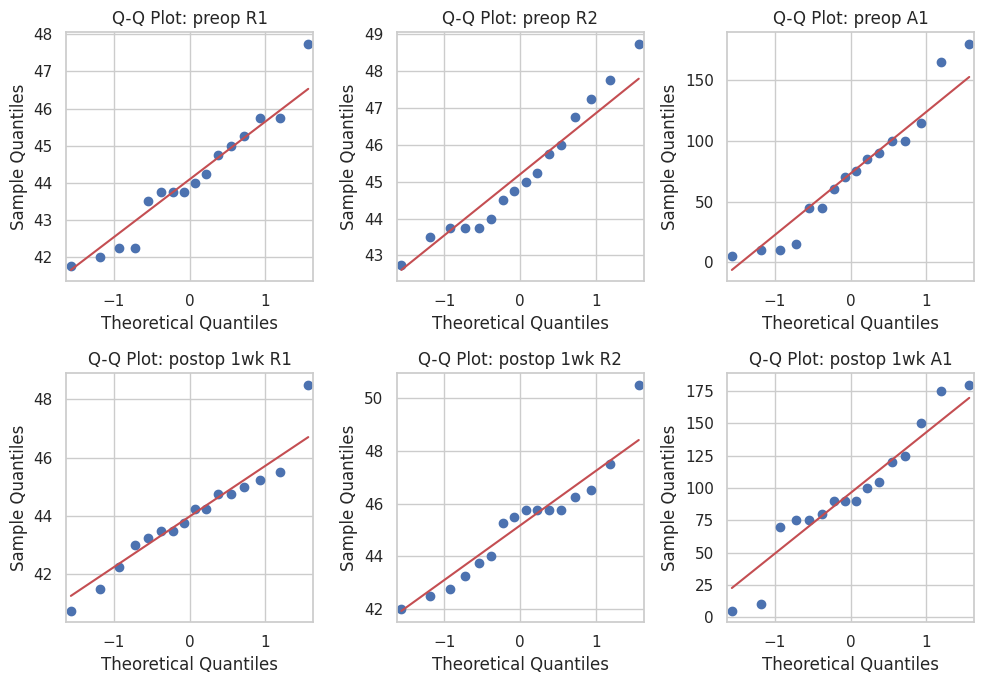

In [254]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Set up a grid of plots
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

# Generate Q-Q plot for each numeric column
for i, col in enumerate(numeric_cols):
    sm.qqplot(df[col].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

In [255]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1
preop R1,1.000000,0.900758,-0.253509,0.808349,0.865799,-0.446495
preop R2,0.900758,1.000000,-0.336842,0.848107,0.913882,-0.537496
preop A1,-0.253509,-0.336842,1.000000,-0.288140,-0.242630,0.619272
postop 1wk R1,0.808349,0.848107,-0.288140,1.000000,0.948182,-0.419830
postop 1wk R2,0.865799,0.913882,-0.242630,0.948182,1.000000,-0.455152
postop 1wk A1,-0.446495,-0.537496,0.619272,-0.419830,-0.455152,1.000000


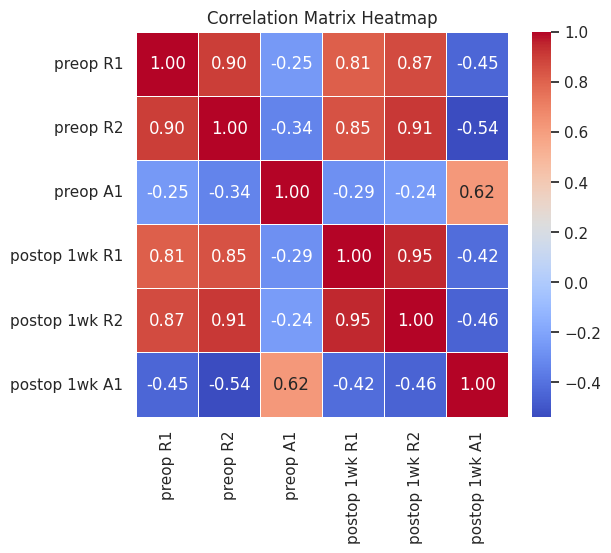

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [257]:
# Unstack the correlation matrix and exclude self-correlations
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Sort pairs by absolute correlation value in descending order
sorted_pairs = corr_pairs.abs().sort_values(ascending=False)

# Display the top correlated pairs (divided by 2 to avoid showing duplicates like (A, B) and (B, A))
print("Top correlated column pairs:")
display(corr_pairs.loc[sorted_pairs.index].iloc[::2].head(10))

Top correlated column pairs:


postop 1wk R2  postop 1wk R1    0.948182
preop R2       postop 1wk R2    0.913882
               preop R1         0.900758
postop 1wk R2  preop R1         0.865799
preop R2       postop 1wk R1    0.848107
postop 1wk R1  preop R1         0.808349
preop A1       postop 1wk A1    0.619272
postop 1wk A1  preop R2        -0.537496
               postop 1wk R2   -0.455152
preop R1       postop 1wk A1   -0.446495
dtype: float64

In [258]:
from scipy.stats import pearsonr
import pandas as pd

# Get numeric columns
cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(cols)

# Initialize dataframes to store correlation coefficients and p-values
corr_df = pd.DataFrame(index=cols, columns=cols, dtype=float)
p_values_df = pd.DataFrame(index=cols, columns=cols, dtype=float)

# Calculate correlation and p-values
for i in range(n_cols):
    for j in range(n_cols):
        if i == j:
            corr_df.iloc[i, j] = 1.0
            p_values_df.iloc[i, j] = 0.0
        else:
            # Drop NaN values pairwise to avoid issues
            valid_data = df[[cols[i], cols[j]]].dropna()
            r, p = pearsonr(valid_data[cols[i]], valid_data[cols[j]])
            corr_df.iloc[i, j] = r
            p_values_df.iloc[i, j] = p

print("Correlation Coefficients (r):")
display(corr_df)

print("\nP-values:")
display(p_values_df)

Correlation Coefficients (r):


,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1
preop R1,1.000000,0.900758,-0.253509,0.808349,0.865799,-0.446495
preop R2,0.900758,1.000000,-0.336842,0.848107,0.913882,-0.537496
preop A1,-0.253509,-0.336842,1.000000,-0.288140,-0.242630,0.619272
postop 1wk R1,0.808349,0.848107,-0.288140,1.000000,0.948182,-0.419830
postop 1wk R2,0.865799,0.913882,-0.242630,0.948182,1.000000,-0.455152
postop 1wk A1,-0.446495,-0.537496,0.619272,-0.419830,-0.455152,1.000000



P-values:


,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1
preop R1,0.000000,1.948716e-06,0.343444,1.508734e-04,1.463386e-05,0.082972
preop R2,0.000002,0.000000e+00,0.202043,3.314703e-05,7.483248e-07,0.031773
preop A1,0.343444,2.020434e-01,0.000000,2.791513e-01,3.652374e-01,0.010524
postop 1wk R1,0.000151,3.314703e-05,0.279151,0.000000e+00,2.344291e-08,0.105460
postop 1wk R2,0.000015,7.483248e-07,0.365237,2.344291e-08,0.000000e+00,0.076476
postop 1wk A1,0.082972,3.177272e-02,0.010524,1.054603e-01,7.647609e-02,0.000000


In [259]:
significant_pairs = []

# Loop through the upper triangle of the matrix to avoid duplicate pairs and self-correlations
for i in range(n_cols):
    for j in range(i + 1, n_cols):
        col1 = cols[i]
        col2 = cols[j]
        r = corr_df.iloc[i, j]
        p = p_values_df.iloc[i, j]

        if p < 0.05:
            significant_pairs.append({
                'Variable 1': col1,
                'Variable 2': col2,
                'Correlation (r)': r,
                'p-value': p
            })

# Convert to DataFrame and sort by the absolute correlation strength
sig_df = pd.DataFrame(significant_pairs)
if not sig_df.empty:
    sig_df = sig_df.iloc[sig_df['Correlation (r)'].abs().argsort()[::-1]]
    print("Statistically Significant Correlations (p < 0.05):")
    display(sig_df)
else:
    print("No statistically significant correlations found at the 0.05 level.")

Statistically Significant Correlations (p < 0.05):


,Variable 1,Variable 2,Correlation (r),p-value
7,postop 1wk R1,postop 1wk R2,0.948182,2.344291e-08
4,preop R2,postop 1wk R2,0.913882,7.483248e-07
0,preop R1,preop R2,0.900758,1.948716e-06
2,preop R1,postop 1wk R2,0.865799,1.463386e-05
3,preop R2,postop 1wk R1,0.848107,3.314703e-05
1,preop R1,postop 1wk R1,0.808349,1.508734e-04
6,preop A1,postop 1wk A1,0.619272,1.052379e-02
5,preop R2,postop 1wk A1,-0.537496,3.177272e-02


In [260]:
pre_post_sig = []

# Separate preop and postop column names
pre_cols = [c for c in cols if 'preop' in c]
post_cols = [c for c in cols if 'postop' in c]

# Check significance between preop and postop variables
for pre in pre_cols:
    for post in post_cols:
        r = corr_df.loc[pre, post]
        p = p_values_df.loc[pre, post]
        if p < 0.05:
            pre_post_sig.append({
                'Pre-operative': pre,
                'Post-operative': post,
                'Correlation (r)': r,
                'p-value': p
            })

pre_post_df = pd.DataFrame(pre_post_sig)
if not pre_post_df.empty:
    pre_post_df = pre_post_df.sort_values(by='p-value')
    print("Statistically Significant Pre-op vs Post-op Correlations (p < 0.05):")
    display(pre_post_df)
else:
    print("No statistically significant pre-op vs post-op correlations found at the 0.05 level.")

Statistically Significant Pre-op vs Post-op Correlations (p < 0.05):


,Pre-operative,Post-operative,Correlation (r),p-value
3,preop R2,postop 1wk R2,0.913882,7.483248e-07
1,preop R1,postop 1wk R2,0.865799,1.463386e-05
2,preop R2,postop 1wk R1,0.848107,3.314703e-05
0,preop R1,postop 1wk R1,0.808349,1.508734e-04
5,preop A1,postop 1wk A1,0.619272,1.052379e-02
4,preop R2,postop 1wk A1,-0.537496,3.177272e-02


In [261]:
import numpy as np
import pandas as pd

def pearson_ci(r, n, confidence=0.95):
    # Fisher's z-transformation
    z = np.arctanh(r)
    # Standard error
    se = 1.0 / np.sqrt(n - 3)
    # Critical value (e.g., 1.96 for 95% CI)
    z_crit = stats.norm.ppf((1 + confidence) / 2)

    # Confidence interval in z space
    z_lo = z - z_crit * se
    z_hi = z + z_crit * se

    # Transform back to r space
    r_lo = np.tanh(z_lo)
    r_hi = np.tanh(z_hi)

    return r_lo, r_hi

n = len(df)
pre_post_ci_sig = []

for pre in pre_cols:
    for post in post_cols:
        r = corr_df.loc[pre, post]
        p = p_values_df.loc[pre, post]
        if p < 0.05:
            r_lo, r_hi = pearson_ci(r, n)
            pre_post_ci_sig.append({
                'Pre-operative': pre,
                'Post-operative': post,
                'Correlation (r)': r,
                'p-value': p,
                '95% CI Lower': r_lo,
                '95% CI Upper': r_hi
            })

pre_post_ci_df = pd.DataFrame(pre_post_ci_sig)
if not pre_post_ci_df.empty:
    pre_post_ci_df = pre_post_ci_df.sort_values(by='p-value')
    print("Significant Pre-op vs Post-op Correlations with 95% Confidence Intervals:")
    display(pre_post_ci_df)
else:
    print("No statistically significant pre-op vs post-op correlations found at the 0.05 level.")

Significant Pre-op vs Post-op Correlations with 95% Confidence Intervals:


,Pre-operative,Post-operative,Correlation (r),p-value,95% CI Lower,95% CI Upper
3,preop R2,postop 1wk R2,0.913882,7.483248e-07,0.764513,0.970111
1,preop R1,postop 1wk R2,0.865799,1.463386e-05,0.648357,0.952647
2,preop R2,postop 1wk R1,0.848107,3.314703e-05,0.608021,0.946073
0,preop R1,postop 1wk R1,0.808349,1.508734e-04,0.521683,0.931000
5,preop A1,postop 1wk A1,0.619272,1.052379e-02,0.178301,0.853097
4,preop R2,postop 1wk A1,-0.537496,3.177272e-02,-0.815831,-0.056969


##  SIA analysis

In [262]:
df.columns

Index(['name', 'preop R1', 'preop R2', 'preop A1', 'postop 1wk R1',
       'postop 1wk R2', 'postop 1wk A1'],
      dtype='object')

In [263]:
df['preop_cyl'] = df['preop R2'] - df['preop R1']
df['postop_cyl'] = df['postop 1wk R2'] - df['postop 1wk R1']
df

,name,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1,preop_cyl,postop_cyl
0,jayamma,43.75,43.75,180,43.75,43.75,180,0.00,0.00
1,gowramma,45.25,47.25,85,45.25,47.50,90,2.00,2.25
2,subbashetty,45.75,46.75,115,45.00,46.25,105,1.00,1.25
3,Lakshmamma,44.25,45.25,90,44.25,45.50,80,1.00,1.25
4,Shivegowda,41.75,43.75,100,40.75,42.00,100,2.00,1.25
5,puttathayamma,45.75,47.75,5,45.50,46.50,10,2.00,1.00
6,nanjundappa,42.00,44.75,45,44.75,45.25,90,2.75,0.50
7,Rani,43.50,43.75,10,41.50,42.50,75,0.25,1.00
8,Nagappa,44.00,45.00,165,43.50,45.75,150,1.00,2.25
9,bellamma,47.75,48.75,10,48.50,50.50,5,1.00,2.00


In [264]:
cylinder = df[['preop_cyl', 'postop_cyl']].describe()
cylinder

,preop_cyl,postop_cyl
count,16.000000,16.000000
mean,1.109375,1.187500
std,0.747043,0.715891
min,0.000000,0.000000
25%,0.687500,0.687500
50%,1.000000,1.125000
75%,1.437500,1.625000
max,2.750000,2.250000


In [265]:
cylinder.kurtosis()

,0
preop_cyl,7.473415
postop_cyl,7.623016


In [266]:
cylinder.skew()

,0
preop_cyl,2.709095
postop_cyl,2.739738


In [267]:
from scipy import stats

for col in ['preop_cyl', 'postop_cyl']:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"{col:11} | Statistic: {stat:.4f} | p-value: {p:.4f} | {'Normal' if p > 0.05 else 'Not Normal'} (alpha=0.05)")

preop_cyl   | Statistic: 0.9167 | p-value: 0.1492 | Normal (alpha=0.05)
postop_cyl  | Statistic: 0.9349 | p-value: 0.2912 | Normal (alpha=0.05)


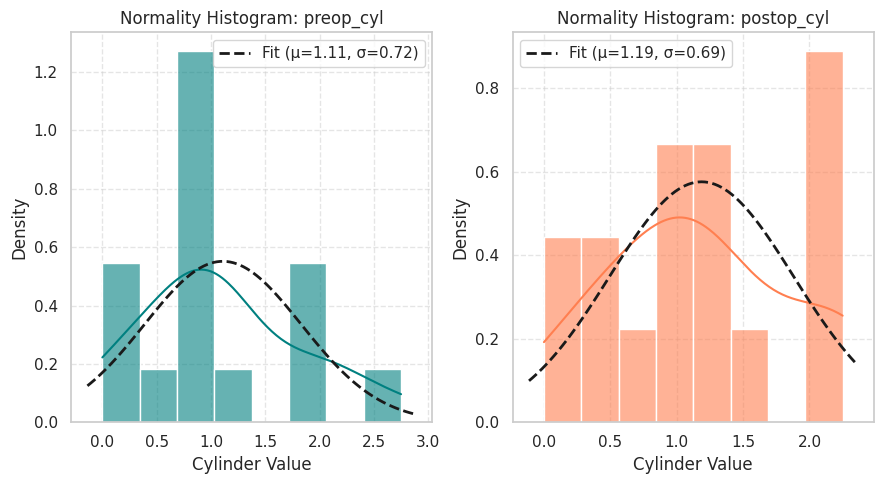

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
cols = ['preop_cyl', 'postop_cyl']
colors = ['teal', 'coral']

for i, col in enumerate(cols):
    # Drop missing values
    data = df[col].dropna()

    # Plot histogram with density
    sns.histplot(data, kde=True, stat="density", color=colors[i], ax=axes[i], bins=8, alpha=0.6)

    # Fit a normal distribution to the data
    mu, std = norm.fit(data)
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    # Plot the fitted normal curve
    axes[i].plot(x, p, 'k--', linewidth=2, label=f'Fit (μ={mu:.2f}, σ={std:.2f})')

    axes[i].set_title(f'Normality Histogram: {col}')
    axes[i].set_xlabel('Cylinder Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

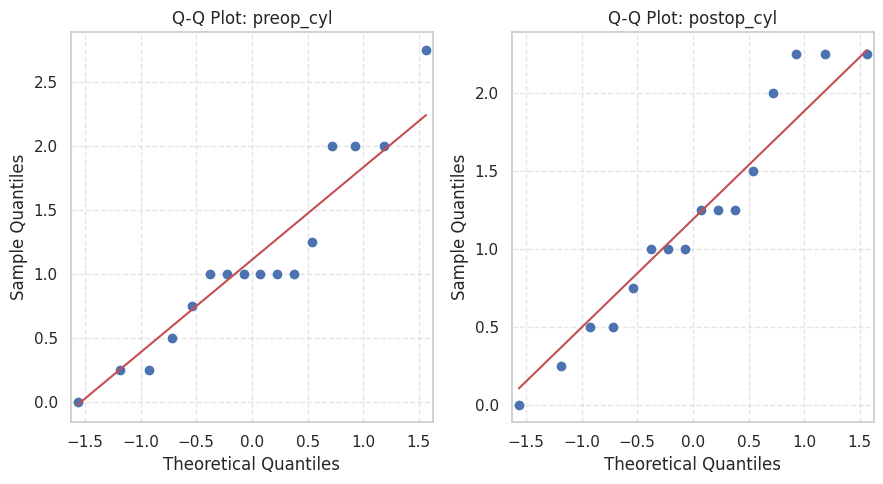

In [269]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
cols = ['preop_cyl', 'postop_cyl']

for i, col in enumerate(cols):
    # Drop missing values for the Q-Q plot
    data = df[col].dropna()

    # Generate Q-Q plot on the corresponding subplot
    sm.qqplot(data, line='s', ax=axes[i])

    axes[i].set_title(f'Q-Q Plot: {col}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## J0 and J45

In [270]:
preop_theta = np.deg2rad(df['preop A1'])
postop_theta = np.deg2rad(df['postop 1wk A1'])

df['preop_J0'] = -(df['preop_cyl'] / 2) * np.cos(2 * preop_theta)
df['preop_J45'] = -(df['preop_cyl'] / 2) * np.sin(2 * preop_theta)
df['postop_J0'] = -(df['postop_cyl'] / 2) * np.cos(2 * postop_theta)
df['postop_J45'] = -(df['postop_cyl'] / 2) * np.sin(2 * postop_theta)
df



,name,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1,preop_cyl,postop_cyl,preop_J0,preop_J45,postop_J0,postop_J45
0,jayamma,43.75,43.75,180,43.75,43.75,180,0.00,0.00,-0.000000e+00,0.000000e+00,-0.000000,0.000000e+00
1,gowramma,45.25,47.25,85,45.25,47.50,90,2.00,2.25,9.848078e-01,-1.736482e-01,1.125000,-1.377728e-16
2,subbashetty,45.75,46.75,115,45.00,46.25,105,1.00,1.25,3.213938e-01,3.830222e-01,0.541266,3.125000e-01
3,Lakshmamma,44.25,45.25,90,44.25,45.50,80,1.00,1.25,5.000000e-01,-6.123234e-17,0.587308,-2.137626e-01
4,Shivegowda,41.75,43.75,100,40.75,42.00,100,2.00,1.25,9.396926e-01,3.420201e-01,0.587308,2.137626e-01
5,puttathayamma,45.75,47.75,5,45.50,46.50,10,2.00,1.00,-9.848078e-01,-1.736482e-01,-0.469846,-1.710101e-01
6,nanjundappa,42.00,44.75,45,44.75,45.25,90,2.75,0.50,-8.419447e-17,-1.375000e+00,0.250000,-3.061617e-17
7,Rani,43.50,43.75,10,41.50,42.50,75,0.25,1.00,-1.174616e-01,-4.275252e-02,0.433013,-2.500000e-01
8,Nagappa,44.00,45.00,165,43.50,45.75,150,1.00,2.25,-4.330127e-01,2.500000e-01,-0.562500,9.742786e-01
9,bellamma,47.75,48.75,10,48.50,50.50,5,1.00,2.00,-4.698463e-01,-1.710101e-01,-0.984808,-1.736482e-01


In [271]:
df[['preop_J0', 'preop_J45', 'postop_J0', 'postop_J45']].describe()

,preop_J0,preop_J45,postop_J0,postop_J45
count,16.000000,16.000000,16.000000,1.600000e+01
mean,0.098466,-0.142676,0.202742,3.105419e-02
std,0.519827,0.406734,0.598761,3.174556e-01
min,-0.984808,-1.375000,-0.984808,-3.750000e-01
25%,-0.196349,-0.243284,-0.117462,-1.836768e-01
50%,0.117462,-0.148005,0.268633,-8.419447e-17
75%,0.349299,0.021376,0.587308,1.415368e-01
max,0.984808,0.383022,1.125000,9.742786e-01


In [272]:
# Select only the J0 and J45 vector component columns
j_columns = ['preop_J0', 'preop_J45', 'postop_J0', 'postop_J45']
j_corr_matrix = df[j_columns].corr()

print("Correlation Matrix for J0 and J45 Columns:")
display(j_corr_matrix)

Correlation Matrix for J0 and J45 Columns:


,preop_J0,preop_J45,postop_J0,postop_J45
preop_J0,1.000000,0.134981,0.825866,-0.022123
preop_J45,0.134981,1.000000,0.016342,0.325845
postop_J0,0.825866,0.016342,1.000000,-0.231481
postop_J45,-0.022123,0.325845,-0.231481,1.000000


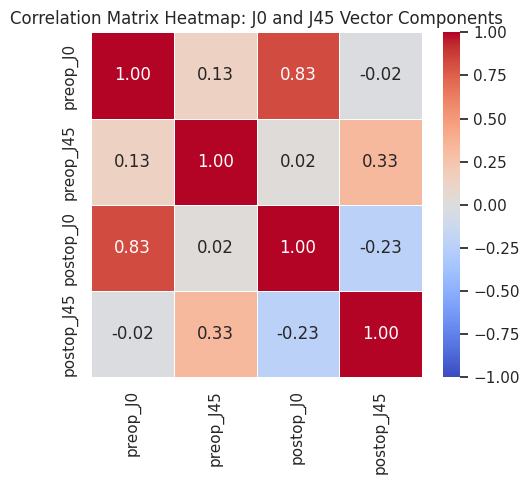

In [273]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting heatmap for the J0 and J45 correlation matrix
plt.figure(figsize=(5, 5))
sns.heatmap(j_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap: J0 and J45 Vector Components')
plt.tight_layout()
plt.show()

In [274]:
from scipy.stats import pearsonr
import pandas as pd

# Define the vector component columns
j_cols = ['preop_J0', 'preop_J45', 'postop_J0', 'postop_J45']
n_j_cols = len(j_cols)

# Initialize DataFrames for J0/J45 correlation coefficients and p-values
j_corr_df = pd.DataFrame(index=j_cols, columns=j_cols, dtype=float)
j_p_values_df = pd.DataFrame(index=j_cols, columns=j_cols, dtype=float)

# Calculate correlation coefficients and p-values
for i in range(n_j_cols):
    for j in range(n_j_cols):
        if i == j:
            j_corr_df.iloc[i, j] = 1.0
            j_p_values_df.iloc[i, j] = 0.0
        else:
            valid_data = df[[j_cols[i], j_cols[j]]].dropna()
            r, p = pearsonr(valid_data[j_cols[i]], valid_data[j_cols[j]])
            j_corr_df.iloc[i, j] = r
            j_p_values_df.iloc[i, j] = p

print("Correlation Coefficients (r) for J0 & J45:")
display(j_corr_df)

print("\nP-values for J0 & J45:")
display(j_p_values_df)

Correlation Coefficients (r) for J0 & J45:


,preop_J0,preop_J45,postop_J0,postop_J45
preop_J0,1.000000,0.134981,0.825866,-0.022123
preop_J45,0.134981,1.000000,0.016342,0.325845
postop_J0,0.825866,0.016342,1.000000,-0.231481
postop_J45,-0.022123,0.325845,-0.231481,1.000000



P-values for J0 & J45:


,preop_J0,preop_J45,postop_J0,postop_J45
preop_J0,0.000000,0.618189,0.000081,0.935187
preop_J45,0.618189,0.000000,0.952101,0.218094
postop_J0,0.000081,0.952101,0.000000,0.388347
postop_J45,0.935187,0.218094,0.388347,0.000000


In [275]:
# Identify and display statistically significant correlations (p < 0.05)
sig_j_pairs = []

for i in range(n_j_cols):
    for j in range(i + 1, n_j_cols):
        col1 = j_cols[i]
        col2 = j_cols[j]
        r = j_corr_df.iloc[i, j]
        p = j_p_values_df.iloc[i, j]

        if p < 0.05:
            sig_j_pairs.append({
                'Variable 1': col1,
                'Variable 2': col2,
                'Correlation (r)': r,
                'p-value': p
            })

sig_j_df = pd.DataFrame(sig_j_pairs)
if not sig_j_df.empty:
    print("Statistically Significant J0/J45 Correlations (p < 0.05):")
    display(sig_j_df.sort_values(by='p-value'))
else:
    print("No statistically significant J0/J45 correlations found at the 0.05 level.")

Statistically Significant J0/J45 Correlations (p < 0.05):


,Variable 1,Variable 2,Correlation (r),p-value
0,preop_J0,postop_J0,0.825866,0.000081


In [276]:
from scipy import stats

j_vector_cols = ['preop_J0', 'preop_J45', 'postop_J0', 'postop_J45']

print("Shapiro-Wilk Normality Test Results for J0 and J45 Columns:")
print("-" * 85)
for col in j_vector_cols:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"{col:11} | Statistic: {stat:.4f} | p-value: {p:.4f} | {'Normal' if p > 0.05 else 'Not Normal'} (alpha=0.05)")

Shapiro-Wilk Normality Test Results for J0 and J45 Columns:
-------------------------------------------------------------------------------------
preop_J0    | Statistic: 0.9666 | p-value: 0.7814 | Normal (alpha=0.05)
preop_J45   | Statistic: 0.8260 | p-value: 0.0062 | Not Normal (alpha=0.05)
postop_J0   | Statistic: 0.9574 | p-value: 0.6143 | Normal (alpha=0.05)
postop_J45  | Statistic: 0.8500 | p-value: 0.0136 | Not Normal (alpha=0.05)


In [277]:
from scipy.stats import ttest_rel

# Drop any rows containing missing J0 values to ensure pair matching
paired_data = df[['preop_J0', 'postop_J0']].dropna()

# Perform paired t-test
t_stat, p_val = ttest_rel(paired_data['preop_J0'], paired_data['postop_J0'])

print("Paired t-test results for J0 (Pre-operative vs Post-operative):")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.4f}")
if p_val < 0.05:
    print("Result      : Statistically significant change in J0 (p < 0.05)")
else:
    print("Result      : No statistically significant change in J0 (p >= 0.05)")

Paired t-test results for J0 (Pre-operative vs Post-operative):
t-statistic : -1.2320
p-value     : 0.2369
Result      : No statistically significant change in J0 (p >= 0.05)


In [278]:
from scipy.stats import ttest_rel, wilcoxon

# Drop any rows containing missing J45 values to ensure paired matching
paired_j45_data = df[['preop_J45', 'postop_J45']].dropna()

# Perform Wilcoxon signed-rank test (preferred due to non-normality)
stat_wilc, p_wilc = wilcoxon(paired_j45_data['preop_J45'], paired_j45_data['postop_J45'])

# Perform paired t-test (parametric)
t_stat_j45, p_val_j45 = ttest_rel(paired_j45_data['preop_J45'], paired_j45_data['postop_J45'])

print("--- Non-parametric Analysis (Preferred) ---")
print("Wilcoxon Signed-Rank Test results for J45:")
print(f"Statistic : {stat_wilc:.4f}")
print(f"p-value   : {p_wilc:.4f}")
if p_wilc < 0.05:
    print("Result    : Statistically significant change in J45 (p < 0.05)")
else:
    print("Result    : No statistically significant change in J45 (p >= 0.05)")

print("\n--- Parametric Analysis ---")
print("Paired t-test results for J45:")
print(f"t-statistic : {t_stat_j45:.4f}")
print(f"p-value     : {p_val_j45:.4f}")
if p_val_j45 < 0.05:
    print("Result      : Statistically significant change in J45 (p < 0.05)")
else:
    print("Result      : No statistically significant change in J45 (p >= 0.05)")

--- Non-parametric Analysis (Preferred) ---
Wilcoxon Signed-Rank Test results for J45:
Statistic : 39.5000
p-value   : 0.2442
Result    : No statistically significant change in J45 (p >= 0.05)

--- Parametric Analysis ---
Paired t-test results for J45:
t-statistic : -1.6286
p-value     : 0.1242
Result      : No statistically significant change in J45 (p >= 0.05)


/tmp/ipykernel_1898/284731581.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1898/284731581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


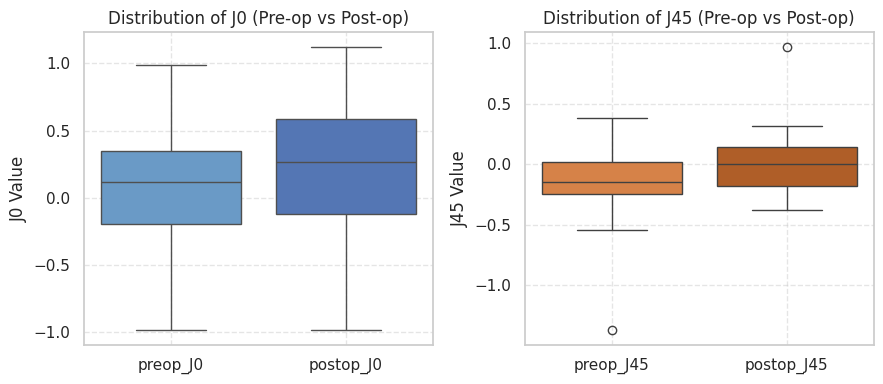

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data in a long format for seaborn
j_data_melted = df[['preop_J0', 'postop_J0', 'preop_J45', 'postop_J45']].melt(
    var_name='Variable',
    value_name='Value'
)

# Create subplots for J0 and J45 side-by-side
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# J0 Boxplot
sns.boxplot(
    data=j_data_melted[j_data_melted['Variable'].isin(['preop_J0', 'postop_J0'])],
    x='Variable',
    y='Value',
    ax=axes[0],
    palette=['#5b9bd5', '#4472c4']
)
axes[0].set_title('Distribution of J0 (Pre-op vs Post-op)')
axes[0].set_xlabel('')
axes[0].set_ylabel('J0 Value')
axes[0].grid(True, linestyle='--', alpha=0.5)

# J45 Boxplot
sns.boxplot(
    data=j_data_melted[j_data_melted['Variable'].isin(['preop_J45', 'postop_J45'])],
    x='Variable',
    y='Value',
    ax=axes[1],
    palette=['#ed7d31', '#c55a11']
)
axes[1].set_title('Distribution of J45 (Pre-op vs Post-op)')
axes[1].set_xlabel('')
axes[1].set_ylabel('J45 Value')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

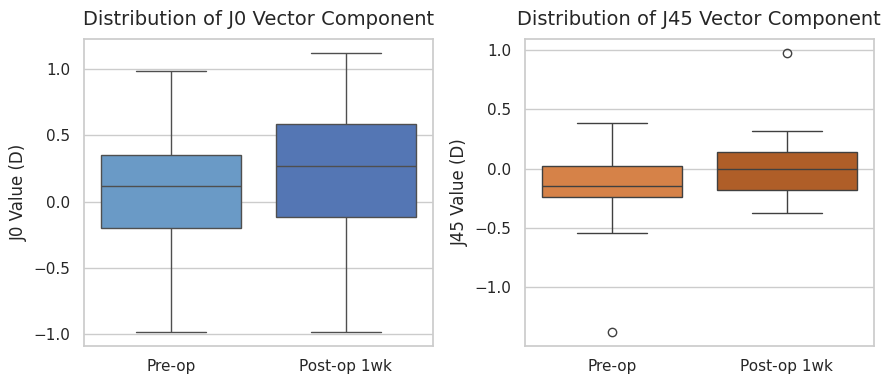

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Melt the J0 and J45 data for easier plotting with seaborn
j_melted = df[['preop_J0', 'postop_J0', 'preop_J45', 'postop_J45']].melt(
    var_name='Timepoint_Component',
    value_name='Value'
)

# Add helper columns for grouping
j_melted['Component'] = j_melted['Timepoint_Component'].apply(lambda x: 'J0' if 'J0' in x else 'J45')
j_melted['Timepoint'] = j_melted['Timepoint_Component'].apply(lambda x: 'Pre-op' if 'pre' in x else 'Post-op 1wk')

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)

# J0 Boxplot
sns.boxplot(
    data=j_melted[j_melted['Component'] == 'J0'],
    x='Timepoint',
    y='Value',
    hue='Timepoint',
    ax=axes[0],
    palette=['#5b9bd5', '#4472c4'],
    legend=False
)
axes[0].set_title('Distribution of J0 Vector Component', fontsize=14, pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('J0 Value (D)', fontsize=12)

# J45 Boxplot
sns.boxplot(
    data=j_melted[j_melted['Component'] == 'J45'],
    x='Timepoint',
    y='Value',
    hue='Timepoint',
    ax=axes[1],
    palette=['#ed7d31', '#c55a11'],
    legend=False
)
axes[1].set_title('Distribution of J45 Vector Component', fontsize=14, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('J45 Value (D)', fontsize=12)

plt.tight_layout()
plt.show()

In [281]:
from scipy.stats import ttest_rel

# Perform paired t-test for J0
j0_paired = df[['preop_J0', 'postop_J0']].dropna()
t_stat_j0, p_val_j0 = ttest_rel(j0_paired['preop_J0'], j0_paired['postop_J0'])

# Perform paired t-test for J45
j45_paired = df[['preop_J45', 'postop_J45']].dropna()
t_stat_j45, p_val_j45 = ttest_rel(j45_paired['preop_J45'], j45_paired['postop_J45'])

print("Paired t-test results for J0 (Pre-op vs Post-op):")
print(f"t-statistic : {t_stat_j0:.4f}")
print(f"p-value     : {p_val_j0:.4f}")
print(f"Result      : {'Statistically significant' if p_val_j0 < 0.05 else 'Not statistically significant'} (alpha=0.05)")

print("\n" + "="*50 + "\n")

print("Paired t-test results for J45 (Pre-op vs Post-op):")
print(f"t-statistic : {t_stat_j45:.4f}")
print(f"p-value     : {p_val_j45:.4f}")
print(f"Result      : {'Statistically significant' if p_val_j45 < 0.05 else 'Not statistically significant'} (alpha=0.05)")

Paired t-test results for J0 (Pre-op vs Post-op):
t-statistic : -1.2320
p-value     : 0.2369
Result      : Not statistically significant (alpha=0.05)


Paired t-test results for J45 (Pre-op vs Post-op):
t-statistic : -1.6286
p-value     : 0.1242
Result      : Not statistically significant (alpha=0.05)


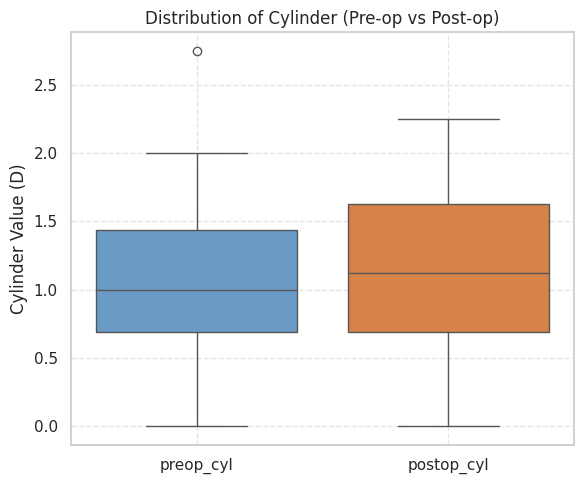

In [282]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the cylinder data in a long format for seaborn
cyl_data_melted = df[['preop_cyl', 'postop_cyl']].melt(
    var_name='Variable',
    value_name='Value'
)

# Create a box plot for cylinder values
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=cyl_data_melted,
    x='Variable',
    y='Value',
    hue='Variable',
    palette=['#5b9bd5', '#ed7d31'],
    legend=False
)

plt.title('Distribution of Cylinder (Pre-op vs Post-op)')
plt.xlabel('')
plt.ylabel('Cylinder Value (D)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [283]:
from scipy.stats import ttest_rel

# Ensure paired matching by removing any rows with missing values
paired_cyl_data = df[['preop_cyl', 'postop_cyl']].dropna()

# Perform paired t-test
t_stat_cyl, p_val_cyl = ttest_rel(paired_cyl_data['preop_cyl'], paired_cyl_data['postop_cyl'])

print("Paired t-test results for Cylinder (Pre-operative vs Post-operative):")
print(f"t-statistic : {t_stat_cyl:.4f}")
print(f"p-value     : {p_val_cyl:.4f}")
if p_val_cyl < 0.05:
    print("Result      : Statistically significant change in Cylinder (p < 0.05)")
else:
    print("Result      : No statistically significant change in Cylinder (p >= 0.05)")

Paired t-test results for Cylinder (Pre-operative vs Post-operative):
t-statistic : -0.3329
p-value     : 0.7438
Result      : No statistically significant change in Cylinder (p >= 0.05)


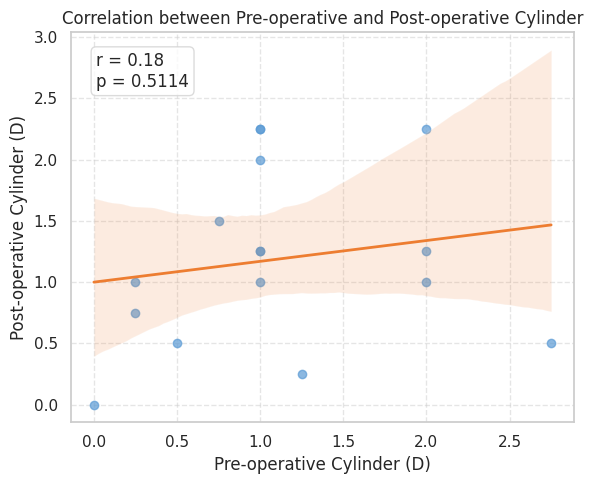

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Drop missing values pairwise to ensure consistent plotting
plot_data = df[['preop_cyl', 'postop_cyl']].dropna()
r_val, p_val = pearsonr(plot_data['preop_cyl'], plot_data['postop_cyl'])

# Create scatter plot with regression line
plt.figure(figsize=(6, 5))
sns.regplot(
    data=plot_data,
    x='preop_cyl',
    y='postop_cyl',
    scatter_kws={'alpha': 0.7, 'color': '#5b9bd5'},
    line_kws={'color': '#ed7d31', 'linewidth': 2}
)

plt.title('Correlation between Pre-operative and Post-operative Cylinder')
plt.xlabel('Pre-operative Cylinder (D)')
plt.ylabel('Post-operative Cylinder (D)')

# Add correlation coefficient and p-value annotation onto the plot
plt.text(
    0.05, 0.95,
    f'r = {r_val:.2f}\np = {p_val:.4f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [285]:
df['preop_magnitude'] = np.sqrt(df['preop_J0']**2 + df['preop_J45']**2)
df['postop_magnitude'] = np.sqrt(df['postop_J0']**2 + df['postop_J45']**2)
df


,name,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1,preop_cyl,postop_cyl,preop_J0,preop_J45,postop_J0,postop_J45,preop_magnitude,postop_magnitude
0,jayamma,43.75,43.75,180,43.75,43.75,180,0.00,0.00,-0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,0.000,0.000
1,gowramma,45.25,47.25,85,45.25,47.50,90,2.00,2.25,9.848078e-01,-1.736482e-01,1.125000,-1.377728e-16,1.000,1.125
2,subbashetty,45.75,46.75,115,45.00,46.25,105,1.00,1.25,3.213938e-01,3.830222e-01,0.541266,3.125000e-01,0.500,0.625
3,Lakshmamma,44.25,45.25,90,44.25,45.50,80,1.00,1.25,5.000000e-01,-6.123234e-17,0.587308,-2.137626e-01,0.500,0.625
4,Shivegowda,41.75,43.75,100,40.75,42.00,100,2.00,1.25,9.396926e-01,3.420201e-01,0.587308,2.137626e-01,1.000,0.625
5,puttathayamma,45.75,47.75,5,45.50,46.50,10,2.00,1.00,-9.848078e-01,-1.736482e-01,-0.469846,-1.710101e-01,1.000,0.500
6,nanjundappa,42.00,44.75,45,44.75,45.25,90,2.75,0.50,-8.419447e-17,-1.375000e+00,0.250000,-3.061617e-17,1.375,0.250
7,Rani,43.50,43.75,10,41.50,42.50,75,0.25,1.00,-1.174616e-01,-4.275252e-02,0.433013,-2.500000e-01,0.125,0.500
8,Nagappa,44.00,45.00,165,43.50,45.75,150,1.00,2.25,-4.330127e-01,2.500000e-01,-0.562500,9.742786e-01,0.500,1.125
9,bellamma,47.75,48.75,10,48.50,50.50,5,1.00,2.00,-4.698463e-01,-1.710101e-01,-0.984808,-1.736482e-01,0.500,1.000


In [286]:
vector_magnitude = df[['preop_magnitude', 'postop_magnitude']].describe()
vector_magnitude

,preop_magnitude,postop_magnitude
count,16.000000,16.000000
mean,0.554688,0.593750
std,0.373521,0.357946
min,0.000000,0.000000
25%,0.343750,0.343750
50%,0.500000,0.562500
75%,0.718750,0.812500
max,1.375000,1.125000


In [287]:
vector_magnitude_corr = df[['preop_magnitude', 'postop_magnitude']].corr()
vector_magnitude_corr

,preop_magnitude,postop_magnitude
preop_magnitude,1.000000,0.177247
postop_magnitude,0.177247,1.000000


In [288]:
vector_magnitude.kurtosis(), vector_magnitude.skew()

(preop_magnitude     7.875015
 postop_magnitude    7.910546
 dtype: float64,
 preop_magnitude     2.799597
 postop_magnitude    2.807394
 dtype: float64)

In [289]:
from scipy import stats

for col in ['preop_magnitude', 'postop_magnitude']:
    stat, p = stats.shapiro(df[col].dropna())
    print(f"{col:16} | Statistic: {stat:.4f} | p-value: {p:.4f} | {'Normal' if p > 0.05 else 'Not Normal'} (alpha=0.05)")

preop_magnitude  | Statistic: 0.9167 | p-value: 0.1492 | Normal (alpha=0.05)
postop_magnitude | Statistic: 0.9349 | p-value: 0.2912 | Normal (alpha=0.05)


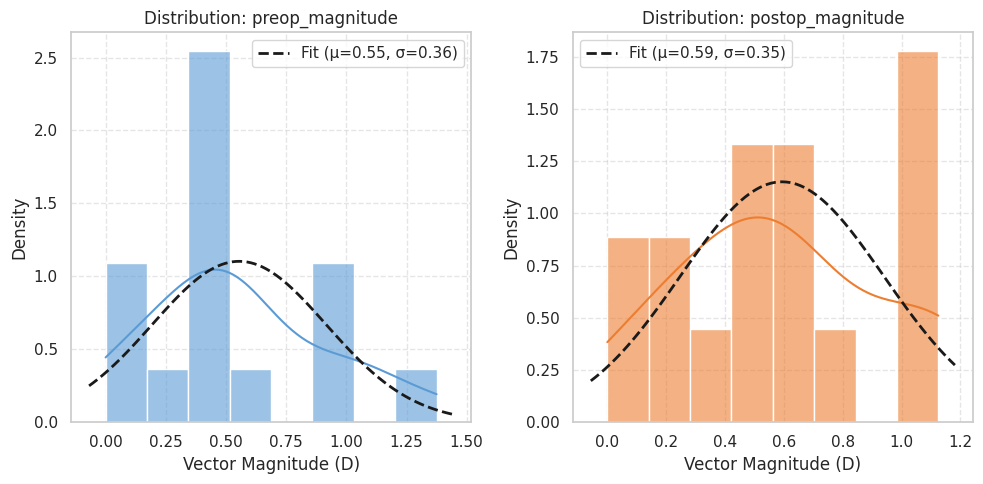

In [290]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
cols = ['preop_magnitude', 'postop_magnitude']
colors = ['#5b9bd5', '#ed7d31']

for i, col in enumerate(cols):
    data = df[col].dropna()

    # Plot histogram with density
    sns.histplot(data, kde=True, stat="density", color=colors[i], ax=axes[i], bins=8, alpha=0.6)

    # Fit a normal distribution
    mu, std = norm.fit(data)
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    # Plot fitted normal curve
    axes[i].plot(x, p, 'k--', linewidth=2, label=f'Fit (μ={mu:.2f}, σ={std:.2f})')

    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel('Vector Magnitude (D)')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [291]:
from scipy.stats import ttest_rel

# Drop any rows containing missing magnitude values to ensure pair matching
paired_magnitudes = df[['preop_magnitude', 'postop_magnitude']].dropna()

# Perform paired t-test
t_stat, p_val = ttest_rel(paired_magnitudes['preop_magnitude'], paired_magnitudes['postop_magnitude'])

print("Paired t-test results for Vector Magnitude (Pre-operative vs Post-operative):")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.4f}")
if p_val < 0.05:
    print("Result      : Statistically significant change in Vector Magnitude (p < 0.05)")
else:
    print("Result      : No statistically significant change in Vector Magnitude (p >= 0.05)")

Paired t-test results for Vector Magnitude (Pre-operative vs Post-operative):
t-statistic : -0.3329
p-value     : 0.7438
Result      : No statistically significant change in Vector Magnitude (p >= 0.05)


Correlation Analysis for Vector Magnitudes (Pre-operative vs Post-operative):
Pearson correlation (r) : 0.1772
p-value                 : 0.5114
95% Confidence Interval : [-0.3491, 0.6186]
Result                  : No statistically significant correlation (p >= 0.05)


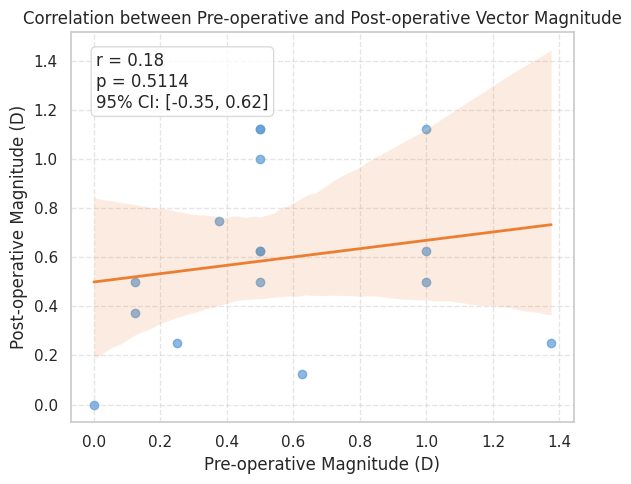

In [292]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Drop missing values pairwise to ensure consistent analysis
corr_data = df[['preop_magnitude', 'postop_magnitude']].dropna()

# Calculate Pearson correlation and p-value
r_val, p_val = stats.pearsonr(corr_data['preop_magnitude'], corr_data['postop_magnitude'])

# Calculate 95% Confidence Interval using Fisher's z-transformation
n = len(corr_data)
z = np.arctanh(r_val)
se = 1.0 / np.sqrt(n - 3)
z_crit = stats.norm.ppf(0.975)
z_lo = z - z_crit * se
z_hi = z + z_crit * se
r_lo = np.tanh(z_lo)
r_hi = np.tanh(z_hi)

print("Correlation Analysis for Vector Magnitudes (Pre-operative vs Post-operative):")
print(f"Pearson correlation (r) : {r_val:.4f}")
print(f"p-value                 : {p_val:.4f}")
print(f"95% Confidence Interval : [{r_lo:.4f}, {r_hi:.4f}]")
if p_val < 0.05:
    print("Result                  : Statistically significant correlation (p < 0.05)")
else:
    print("Result                  : No statistically significant correlation (p >= 0.05)")

# Plot scatter with regression line
plt.figure(figsize=(6, 5))
sns.regplot(
    data=corr_data,
    x='preop_magnitude',
    y='postop_magnitude',
    scatter_kws={'alpha': 0.7, 'color': '#5b9bd5'},
    line_kws={'color': '#ed7d31', 'linewidth': 2}
)

plt.title('Correlation between Pre-operative and Post-operative Vector Magnitude')
plt.xlabel('Pre-operative Magnitude (D)')
plt.ylabel('Post-operative Magnitude (D)')

# Add annotation onto the plot
plt.text(
    0.05, 0.95,
    f'r = {r_val:.2f}\np = {p_val:.4f}\n95% CI: [{r_lo:.2f}, {r_hi:.2f}]',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray')
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## SIA axis

In [293]:
df['preop_vector_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['preop_J45'], df['preop_J0'])
    )
)
df['postop_vector_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['postop_J45'], df['postop_J0'])
    )
)
df

,name,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1,preop_cyl,postop_cyl,preop_J0,preop_J45,postop_J0,postop_J45,preop_magnitude,postop_magnitude,preop_vector_axis,postop_vector_axis
0,jayamma,43.75,43.75,180,43.75,43.75,180,0.00,0.00,-0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,0.000,0.000,9.000000e+01,9.000000e+01
1,gowramma,45.25,47.25,85,45.25,47.50,90,2.00,2.25,9.848078e-01,-1.736482e-01,1.125000,-1.377728e-16,1.000,1.125,-5.000000e+00,-3.508355e-15
2,subbashetty,45.75,46.75,115,45.00,46.25,105,1.00,1.25,3.213938e-01,3.830222e-01,0.541266,3.125000e-01,0.500,0.625,2.500000e+01,1.500000e+01
3,Lakshmamma,44.25,45.25,90,44.25,45.50,80,1.00,1.25,5.000000e-01,-6.123234e-17,0.587308,-2.137626e-01,0.500,0.625,-3.508355e-15,-1.000000e+01
4,Shivegowda,41.75,43.75,100,40.75,42.00,100,2.00,1.25,9.396926e-01,3.420201e-01,0.587308,2.137626e-01,1.000,0.625,1.000000e+01,1.000000e+01
5,puttathayamma,45.75,47.75,5,45.50,46.50,10,2.00,1.00,-9.848078e-01,-1.736482e-01,-0.469846,-1.710101e-01,1.000,0.500,-8.500000e+01,-8.000000e+01
6,nanjundappa,42.00,44.75,45,44.75,45.25,90,2.75,0.50,-8.419447e-17,-1.375000e+00,0.250000,-3.061617e-17,1.375,0.250,-4.500000e+01,-3.508355e-15
7,Rani,43.50,43.75,10,41.50,42.50,75,0.25,1.00,-1.174616e-01,-4.275252e-02,0.433013,-2.500000e-01,0.125,0.500,-8.000000e+01,-1.500000e+01
8,Nagappa,44.00,45.00,165,43.50,45.75,150,1.00,2.25,-4.330127e-01,2.500000e-01,-0.562500,9.742786e-01,0.500,1.125,7.500000e+01,6.000000e+01
9,bellamma,47.75,48.75,10,48.50,50.50,5,1.00,2.00,-4.698463e-01,-1.710101e-01,-0.984808,-1.736482e-01,0.500,1.000,-8.000000e+01,-8.500000e+01


In [294]:
df['preop_vector_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['preop_J45'], df['preop_J0'])
    )
) % 180
df['postop_vector_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['postop_J45'], df['postop_J0'])
    )
) % 180
df

,name,preop R1,preop R2,preop A1,postop 1wk R1,postop 1wk R2,postop 1wk A1,preop_cyl,postop_cyl,preop_J0,preop_J45,postop_J0,postop_J45,preop_magnitude,postop_magnitude,preop_vector_axis,postop_vector_axis
0,jayamma,43.75,43.75,180,43.75,43.75,180,0.00,0.00,-0.000000e+00,0.000000e+00,-0.000000,0.000000e+00,0.000,0.000,90.0,90.0
1,gowramma,45.25,47.25,85,45.25,47.50,90,2.00,2.25,9.848078e-01,-1.736482e-01,1.125000,-1.377728e-16,1.000,1.125,175.0,180.0
2,subbashetty,45.75,46.75,115,45.00,46.25,105,1.00,1.25,3.213938e-01,3.830222e-01,0.541266,3.125000e-01,0.500,0.625,25.0,15.0
3,Lakshmamma,44.25,45.25,90,44.25,45.50,80,1.00,1.25,5.000000e-01,-6.123234e-17,0.587308,-2.137626e-01,0.500,0.625,180.0,170.0
4,Shivegowda,41.75,43.75,100,40.75,42.00,100,2.00,1.25,9.396926e-01,3.420201e-01,0.587308,2.137626e-01,1.000,0.625,10.0,10.0
5,puttathayamma,45.75,47.75,5,45.50,46.50,10,2.00,1.00,-9.848078e-01,-1.736482e-01,-0.469846,-1.710101e-01,1.000,0.500,95.0,100.0
6,nanjundappa,42.00,44.75,45,44.75,45.25,90,2.75,0.50,-8.419447e-17,-1.375000e+00,0.250000,-3.061617e-17,1.375,0.250,135.0,180.0
7,Rani,43.50,43.75,10,41.50,42.50,75,0.25,1.00,-1.174616e-01,-4.275252e-02,0.433013,-2.500000e-01,0.125,0.500,100.0,165.0
8,Nagappa,44.00,45.00,165,43.50,45.75,150,1.00,2.25,-4.330127e-01,2.500000e-01,-0.562500,9.742786e-01,0.500,1.125,75.0,60.0
9,bellamma,47.75,48.75,10,48.50,50.50,5,1.00,2.00,-4.698463e-01,-1.710101e-01,-0.984808,-1.736482e-01,0.500,1.000,100.0,95.0


In [295]:
import numpy as np

# SIA vector components
df['SIA_J0'] = df['postop_J0'] - df['preop_J0']
df['SIA_J45'] = df['postop_J45'] - df['preop_J45']

# SIA magnitude
df['SIA_magnitude'] = np.sqrt(
    df['SIA_J0']**2 + df['SIA_J45']**2
)

# SIA axis (0–180 degrees)
df['SIA_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['SIA_J45'], df['SIA_J0'])
    )
) % 180

In [296]:
sia_table = df[
    ['name',
     'preop_J0', 'preop_J45',
     'postop_J0', 'postop_J45',
     'SIA_J0', 'SIA_J45',
     'SIA_magnitude', 'SIA_axis']
].copy()

print(sia_table.round(3))

             name  preop_J0  preop_J45  postop_J0  postop_J45  SIA_J0  \
0        jayamma     -0.000      0.000     -0.000       0.000   0.000   
1        gowramma     0.985     -0.174      1.125      -0.000   0.140   
2     subbashetty     0.321      0.383      0.541       0.313   0.220   
3      Lakshmamma     0.500     -0.000      0.587      -0.214   0.087   
4      Shivegowda     0.940      0.342      0.587       0.214  -0.352   
5   puttathayamma    -0.985     -0.174     -0.470      -0.171   0.515   
6     nanjundappa    -0.000     -1.375      0.250      -0.000   0.250   
7            Rani    -0.117     -0.043      0.433      -0.250   0.550   
8         Nagappa    -0.433      0.250     -0.563       0.974  -0.129   
9        bellamma    -0.470     -0.171     -0.985      -0.174  -0.515   
10      shanthmma    -0.000     -0.125      0.287      -0.241   0.287   
11     marilingu      0.312     -0.541      0.043       0.117  -0.270   
12       meenakhi     0.287     -0.241      0.650  

In [297]:
preop_J0_centroid = df['preop_J0'].mean()
preop_J45_centroid = df['preop_J45'].mean()

preop_centroid_magnitude = np.sqrt(
    preop_J0_centroid**2 + preop_J45_centroid**2
)

preop_centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(preop_J45_centroid, preop_J0_centroid)
    )
) % 180

print("Pre-op centroid J0:", preop_J0_centroid)
print("Pre-op centroid J45:", preop_J45_centroid)
print("Pre-op centroid magnitude:", preop_centroid_magnitude)
print("Pre-op centroid axis:", preop_centroid_axis)

Pre-op centroid J0: 0.09846597856949124
Pre-op centroid J45: -0.1426764234495972
Pre-op centroid magnitude: 0.17335544624849913
Pre-op centroid axis: 152.30545563645254


In [298]:
postop_J0_centroid = df['postop_J0'].mean()
postop_J45_centroid = df['postop_J45'].mean()

postop_centroid_magnitude = np.sqrt(
    postop_J0_centroid**2 + postop_J45_centroid**2
)

postop_centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(postop_J45_centroid, postop_J0_centroid)
    )
) % 180

print("Post-op centroid J0:", postop_J0_centroid)
print("Post-op centroid J45:", postop_J45_centroid)
print("Post-op centroid magnitude:", postop_centroid_magnitude)
print("Post-op centroid axis:", postop_centroid_axis)

Post-op centroid J0: 0.2027421657657667
Post-op centroid J45: 0.031054187104568094
Post-op centroid magnitude: 0.20510667545479633
Post-op centroid axis: 4.354180112111647


In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ============================================================
# 1. CALCULATE SIA COMPONENTS
# ============================================================

df['SIA_J0'] = df['postop_J0'] - df['preop_J0']
df['SIA_J45'] = df['postop_J45'] - df['preop_J45']


# ============================================================
# 2. FUNCTION TO CALCULATE CENTROID
# ============================================================

def calculate_centroid(j0, j45):

    j0 = pd.to_numeric(j0, errors='coerce')
    j45 = pd.to_numeric(j45, errors='coerce')

    valid = j0.notna() & j45.notna()

    x = j0[valid].to_numpy()
    y = j45[valid].to_numpy()

    centroid_J0 = np.mean(x)
    centroid_J45 = np.mean(y)

    magnitude = np.sqrt(
        centroid_J0**2 + centroid_J45**2
    )

    axis = (
        0.5 *
        np.degrees(
            np.arctan2(centroid_J45, centroid_J0)
        )
    ) % 180

    return {
        'n': len(x),
        'J0': centroid_J0,
        'J45': centroid_J45,
        'Magnitude': magnitude,
        'Axis': axis
    }


# ============================================================
# 3. CALCULATE PRE-OP, POST-OP AND SIA CENTROIDS
# ============================================================

preop_centroid = calculate_centroid(
    df['preop_J0'],
    df['preop_J45']
)

postop_centroid = calculate_centroid(
    df['postop_J0'],
    df['postop_J45']
)

sia_centroid = calculate_centroid(
    df['SIA_J0'],
    df['SIA_J45']
)


# ============================================================
# 4. DISPLAY RESULTS
# ============================================================

centroid_table = pd.DataFrame([
    ['Pre-op',
     preop_centroid['n'],
     preop_centroid['J0'],
     preop_centroid['J45'],
     preop_centroid['Magnitude'],
     preop_centroid['Axis']],

    ['Post-op 1 week',
     postop_centroid['n'],
     postop_centroid['J0'],
     postop_centroid['J45'],
     postop_centroid['Magnitude'],
     postop_centroid['Axis']],

    ['SIA',
     sia_centroid['n'],
     sia_centroid['J0'],
     sia_centroid['J45'],
     sia_centroid['Magnitude'],
     sia_centroid['Axis']]
],
columns=[
    'Vector',
    'N',
    'Centroid J0 (D)',
    'Centroid J45 (D)',
    'Centroid Magnitude (D)',
    'Centroid Axis (°)'
])

print(
    centroid_table.round({
        'Centroid J0 (D)': 3,
        'Centroid J45 (D)': 3,
        'Centroid Magnitude (D)': 3,
        'Centroid Axis (°)': 1
    })
)

           Vector   N  Centroid J0 (D)  Centroid J45 (D)  \
0          Pre-op  16            0.098            -0.143   
1  Post-op 1 week  16            0.203             0.031   
2             SIA  16            0.104             0.174   

   Centroid Magnitude (D)  Centroid Axis (°)  
0                   0.173              152.3  
1                   0.205                4.4  
2                   0.203               29.5  


In [300]:
def confidence_ellipse_parameters(j0, j45, confidence=0.95):

    j0 = pd.to_numeric(j0, errors='coerce')
    j45 = pd.to_numeric(j45, errors='coerce')

    valid = j0.notna() & j45.notna()

    x = j0[valid].to_numpy()
    y = j45[valid].to_numpy()

    n = len(x)

    # Centroid
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Covariance matrix
    cov = np.cov(x, y)

    # Eigenvalues/eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort largest eigenvalue first
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Chi-square value for 95% ellipse, 2 df
    chi2_95 = 5.991

    # Standard error covariance of the centroid
    cov_centroid = cov / n

    # Eigenvalues of centroid covariance
    eig_centroid, vec_centroid = np.linalg.eigh(cov_centroid)

    order = eig_centroid.argsort()[::-1]
    eig_centroid = eig_centroid[order]
    vec_centroid = vec_centroid[:, order]

    # Full axis lengths of 95% confidence ellipse
    width = 2 * np.sqrt(chi2_95 * eig_centroid[0])
    height = 2 * np.sqrt(chi2_95 * eig_centroid[1])

    # Rotation angle
    angle = np.degrees(
        np.arctan2(
            vec_centroid[1, 0],
            vec_centroid[0, 0]
        )
    )

    return {
        'n': n,
        'center_x': mean_x,
        'center_y': mean_y,
        'width': width,
        'height': height,
        'angle': angle
    }

In [301]:
preop_ellipse = confidence_ellipse_parameters(
    df['preop_J0'],
    df['preop_J45']
)

postop_ellipse = confidence_ellipse_parameters(
    df['postop_J0'],
    df['postop_J45']
)

sia_ellipse = confidence_ellipse_parameters(
    df['SIA_J0'],
    df['SIA_J45']
)

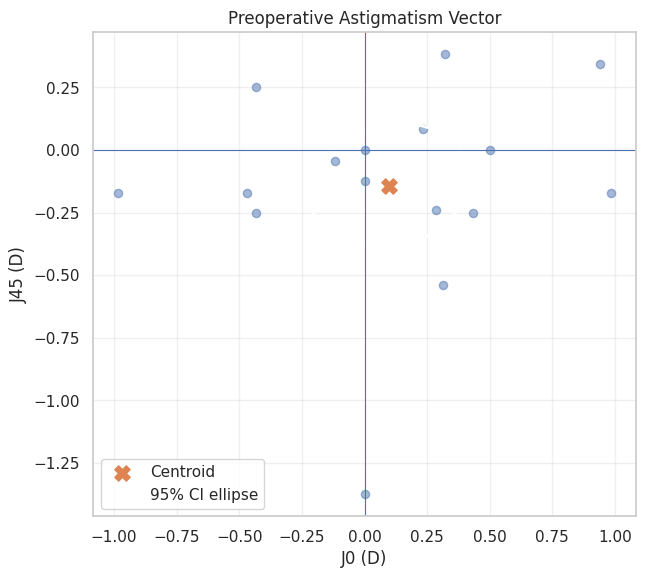

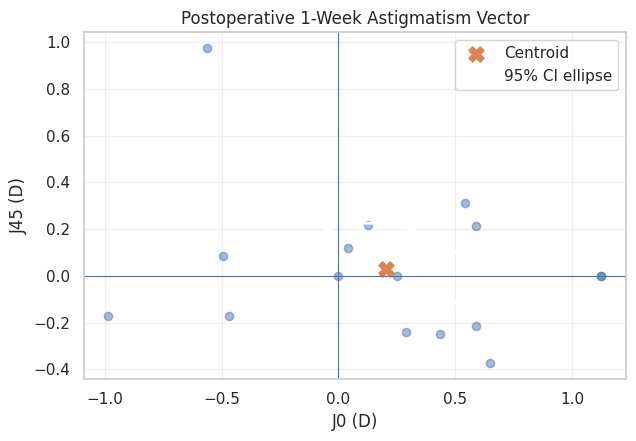

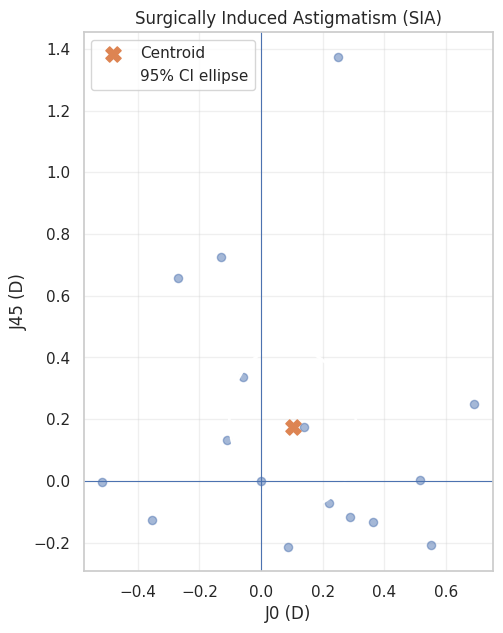

In [302]:
def plot_vector_ellipse(j0, j45, ellipse_params,
                        title, centroid):

    fig, ax = plt.subplots(figsize=(7, 7))

    # Individual vectors
    ax.scatter(
        j0,
        j45,
        alpha=0.5,
        s=35
    )

    # Centroid
    ax.scatter(
        centroid['J0'],
        centroid['J45'],
        marker='X',
        s=120,
        label='Centroid'
    )

    # 95% confidence ellipse
    ellipse = Ellipse(
        xy=(
            ellipse_params['center_x'],
            ellipse_params['center_y']
        ),
        width=ellipse_params['width'],
        height=ellipse_params['height'],
        angle=ellipse_params['angle'],
        fill=False,
        linewidth=2,
        label='95% CI ellipse'
    )

    ax.add_patch(ellipse)

    # Reference axes
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_xlabel('J0 (D)')
    ax.set_ylabel('J45 (D)')
    ax.set_title(title)

    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)

    ax.legend()

    plt.show()


# PRE-OP
plot_vector_ellipse(
    df['preop_J0'],
    df['preop_J45'],
    preop_ellipse,
    'Preoperative Astigmatism Vector',
    preop_centroid
)


# POST-OP
plot_vector_ellipse(
    df['postop_J0'],
    df['postop_J45'],
    postop_ellipse,
    'Postoperative 1-Week Astigmatism Vector',
    postop_centroid
)


# SIA
plot_vector_ellipse(
    df['SIA_J0'],
    df['SIA_J45'],
    sia_ellipse,
    'Surgically Induced Astigmatism (SIA)',
    sia_centroid
)

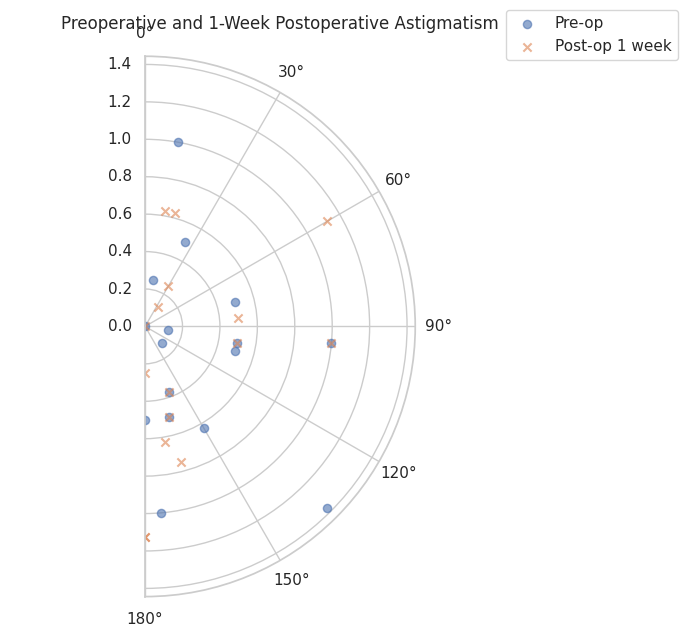

In [303]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PRE-OP: magnitude and axis
# ---------------------------------------------------------

df['preop_magnitude'] = np.sqrt(
    df['preop_J0']**2 + df['preop_J45']**2
)

df['preop_axis'] = (
    0.5 * np.degrees(
        np.arctan2(
            df['preop_J45'],
            df['preop_J0']
        )
    )
) % 180


# ---------------------------------------------------------
# POST-OP 1 WEEK: magnitude and axis
# ---------------------------------------------------------

df['postop_magnitude'] = np.sqrt(
    df['postop_J0']**2 + df['postop_J45']**2
)

df['postop_axis'] = (
    0.5 * np.degrees(
        np.arctan2(
            df['postop_J45'],
            df['postop_J0']
        )
    )
) % 180


# ---------------------------------------------------------
# POLAR PLOT
# ---------------------------------------------------------

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Convert degrees to radians
preop_theta = np.deg2rad(df['preop_axis'])
postop_theta = np.deg2rad(df['postop_axis'])

# Plot individual eyes
ax.scatter(
    preop_theta,
    df['preop_magnitude'],
    s=35,
    alpha=0.6,
    label='Pre-op'
)

ax.scatter(
    postop_theta,
    df['postop_magnitude'],
    s=35,
    alpha=0.6,
    marker='x',
    label='Post-op 1 week'
)

# Ophthalmic astigmatism convention: 0–180°
ax.set_thetamin(0)
ax.set_thetamax(180)

# Put 0° at the top
ax.set_theta_zero_location('N')

# Clockwise direction
ax.set_theta_direction(-1)

ax.set_thetagrids(
    [0, 30, 60, 90, 120, 150, 180],
    labels=['0°', '30°', '60°', '90°',
            '120°', '150°', '180°']
)

ax.set_title(
    'Preoperative and 1-Week Postoperative Astigmatism',
    pad=20
)

ax.set_rlabel_position(225)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.10)
)

plt.tight_layout()
plt.show()

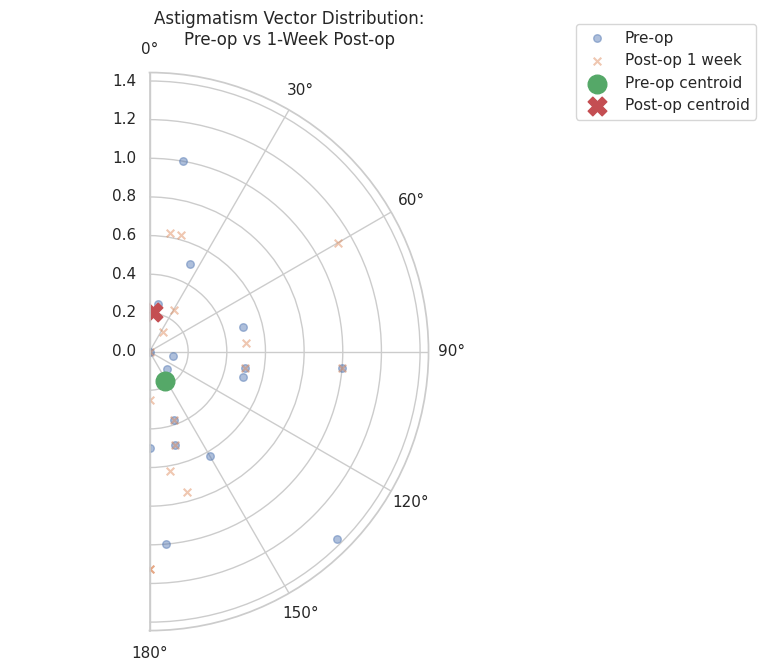

In [304]:
# ---------------------------------------------------------
# CENTROIDS
# ---------------------------------------------------------

preop_centroid_J0 = df['preop_J0'].mean()
preop_centroid_J45 = df['preop_J45'].mean()

postop_centroid_J0 = df['postop_J0'].mean()
postop_centroid_J45 = df['postop_J45'].mean()

preop_centroid_mag = np.sqrt(
    preop_centroid_J0**2 + preop_centroid_J45**2
)

postop_centroid_mag = np.sqrt(
    postop_centroid_J0**2 + postop_centroid_J45**2
)

preop_centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(
            preop_centroid_J45,
            preop_centroid_J0
        )
    )
) % 180

postop_centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(
            postop_centroid_J45,
            postop_centroid_J0
        )
    )
) % 180


# ---------------------------------------------------------
# POLAR PLOT
# ---------------------------------------------------------

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Individual observations
ax.scatter(
    np.deg2rad(df['preop_axis']),
    df['preop_magnitude'],
    s=30,
    alpha=0.45,
    label='Pre-op'
)

ax.scatter(
    np.deg2rad(df['postop_axis']),
    df['postop_magnitude'],
    s=30,
    alpha=0.45,
    marker='x',
    label='Post-op 1 week'
)

# Centroids
ax.scatter(
    np.deg2rad(preop_centroid_axis),
    preop_centroid_mag,
    s=180,
    marker='o',
    label='Pre-op centroid'
)

ax.scatter(
    np.deg2rad(postop_centroid_axis),
    postop_centroid_mag,
    s=180,
    marker='X',
    label='Post-op centroid'
)

# Axis convention
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetamin(0)
ax.set_thetamax(180)

ax.set_thetagrids(
    [0, 30, 60, 90, 120, 150, 180]
)

ax.set_title(
    'Astigmatism Vector Distribution:\n'
    'Pre-op vs 1-Week Post-op',
    pad=20
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.10)
)

plt.tight_layout()
plt.show()

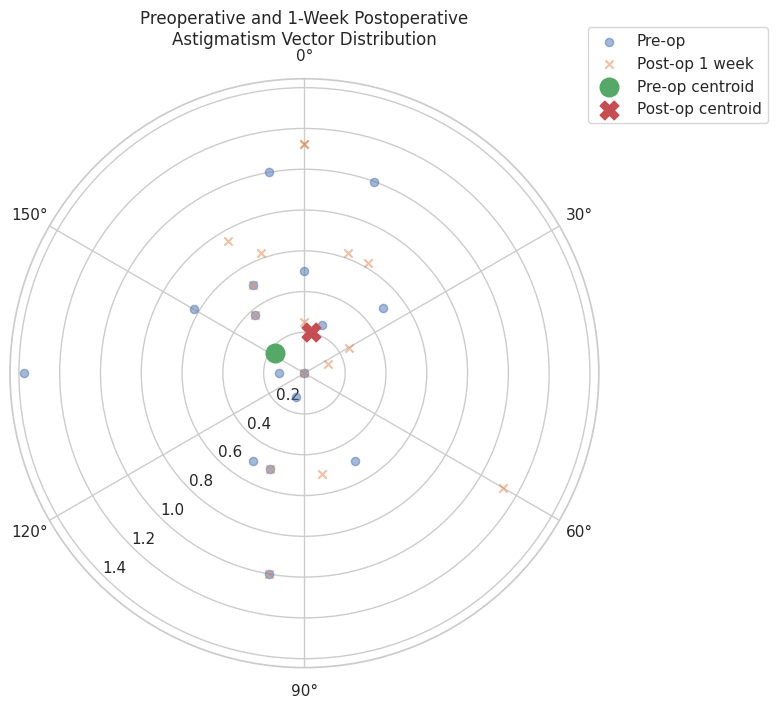

In [305]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. CONVERT J0/J45 TO ASTIGMATISM MAGNITUDE AND AXIS
# ==========================================================

df['preop_magnitude'] = np.sqrt(
    df['preop_J0']**2 + df['preop_J45']**2
)

df['postop_magnitude'] = np.sqrt(
    df['postop_J0']**2 + df['postop_J45']**2
)

df['preop_axis'] = (
    0.5 * np.degrees(
        np.arctan2(
            df['preop_J45'],
            df['preop_J0']
        )
    )
) % 180

df['postop_axis'] = (
    0.5 * np.degrees(
        np.arctan2(
            df['postop_J45'],
            df['postop_J0']
        )
    )
) % 180


# ==========================================================
# 2. DOUBLE-ANGLE TRANSFORMATION
# ==========================================================

preop_theta = np.deg2rad(2 * df['preop_axis'])
postop_theta = np.deg2rad(2 * df['postop_axis'])


# ==========================================================
# 3. CENTROIDS IN J0/J45 SPACE
# ==========================================================

preop_J0_mean = df['preop_J0'].mean()
preop_J45_mean = df['preop_J45'].mean()

postop_J0_mean = df['postop_J0'].mean()
postop_J45_mean = df['postop_J45'].mean()

preop_centroid_mag = np.sqrt(
    preop_J0_mean**2 + preop_J45_mean**2
)

postop_centroid_mag = np.sqrt(
    postop_J0_mean**2 + postop_J45_mean**2
)

preop_centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(
            preop_J45_mean,
            preop_J0_mean
        )
    )
) % 180

postop_centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(
            postop_J45_mean,
            postop_J0_mean
        )
    )
) % 180


# ==========================================================
# 4. DOUBLE-ANGLE CENTROID ANGLES
# ==========================================================

preop_centroid_theta = np.deg2rad(
    2 * preop_centroid_axis
)

postop_centroid_theta = np.deg2rad(
    2 * postop_centroid_axis
)


# ==========================================================
# 5. PLOT
# ==========================================================

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Individual pre-op vectors
ax.scatter(
    preop_theta,
    df['preop_magnitude'],
    s=35,
    alpha=0.5,
    label='Pre-op'
)

# Individual postoperative vectors
ax.scatter(
    postop_theta,
    df['postop_magnitude'],
    s=35,
    alpha=0.5,
    marker='x',
    label='Post-op 1 week'
)

# Pre-op centroid
ax.scatter(
    preop_centroid_theta,
    preop_centroid_mag,
    s=180,
    marker='o',
    label='Pre-op centroid'
)

# Post-op centroid
ax.scatter(
    postop_centroid_theta,
    postop_centroid_mag,
    s=180,
    marker='X',
    label='Post-op centroid'
)


# ==========================================================
# 6. DOUBLE-ANGLE AXIS LABELS
# ==========================================================

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_thetagrids(
    [0, 60, 120, 180, 240, 300],
    labels=[
        '0°',
        '30°',
        '60°',
        '90°',
        '120°',
        '150°'
    ]
)

ax.set_title(
    'Preoperative and 1-Week Postoperative\n'
    'Astigmatism Vector Distribution',
    pad=25
)

ax.set_rlabel_position(225)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.30, 1.10)
)

plt.tight_layout()
plt.show()

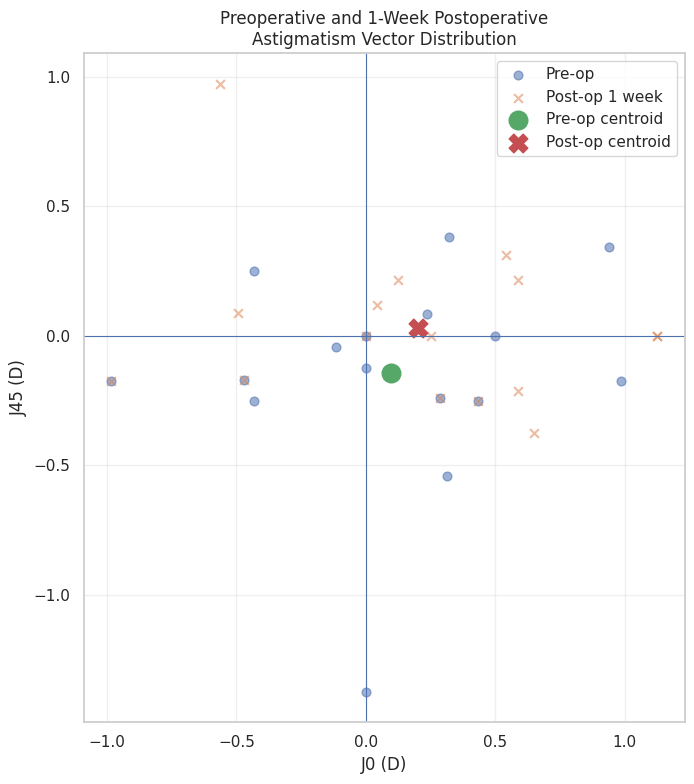

In [306]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CENTROIDS
# ==========================================================

preop_J0_mean = df['preop_J0'].mean()
preop_J45_mean = df['preop_J45'].mean()

postop_J0_mean = df['postop_J0'].mean()
postop_J45_mean = df['postop_J45'].mean()


# ==========================================================
# CARTESIAN PLOT
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Individual pre-op vectors
ax.scatter(
    df['preop_J0'],
    df['preop_J45'],
    s=40,
    alpha=0.55,
    label='Pre-op'
)

# Individual post-op vectors
ax.scatter(
    df['postop_J0'],
    df['postop_J45'],
    s=40,
    alpha=0.55,
    marker='x',
    label='Post-op 1 week'
)

# Pre-op centroid
ax.scatter(
    preop_J0_mean,
    preop_J45_mean,
    s=180,
    marker='o',
    label='Pre-op centroid'
)

# Post-op centroid
ax.scatter(
    postop_J0_mean,
    postop_J45_mean,
    s=180,
    marker='X',
    label='Post-op centroid'
)

# ==========================================================
# REFERENCE AXES
# ==========================================================

ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)

# ==========================================================
# LABELS
# ==========================================================

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')

ax.set_title(
    'Preoperative and 1-Week Postoperative\n'
    'Astigmatism Vector Distribution'
)

ax.set_aspect('equal', adjustable='box')

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

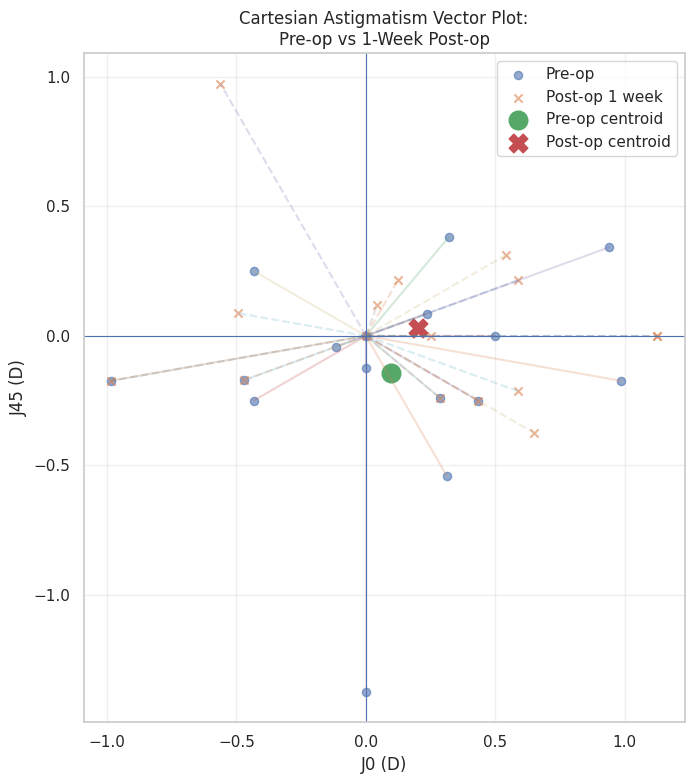

In [307]:
fig, ax = plt.subplots(figsize=(8, 8))

# Pre-op vectors
for x, y in zip(df['preop_J0'], df['preop_J45']):
    ax.plot(
        [0, x],
        [0, y],
        alpha=0.25
    )

# Post-op vectors
for x, y in zip(df['postop_J0'], df['postop_J45']):
    ax.plot(
        [0, x],
        [0, y],
        alpha=0.25,
        linestyle='--'
    )

# Individual points
ax.scatter(
    df['preop_J0'],
    df['preop_J45'],
    s=35,
    alpha=0.6,
    label='Pre-op'
)

ax.scatter(
    df['postop_J0'],
    df['postop_J45'],
    s=35,
    alpha=0.6,
    marker='x',
    label='Post-op 1 week'
)

# Centroids
ax.scatter(
    preop_J0_mean,
    preop_J45_mean,
    s=180,
    marker='o',
    label='Pre-op centroid'
)

ax.scatter(
    postop_J0_mean,
    postop_J45_mean,
    s=180,
    marker='X',
    label='Post-op centroid'
)

# Origin
ax.scatter(
    0, 0,
    s=60,
    marker='+'
)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')

ax.set_title(
    'Cartesian Astigmatism Vector Plot:\n'
    'Pre-op vs 1-Week Post-op'
)

ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [308]:
import numpy as np

def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan

    axis = axis % 180

    if axis <= 30 or axis >= 150:
        return 'ATR'
    elif 60 <= axis <= 120:
        return 'WTR'
    else:
        return 'Oblique'


df['preop_astigmatism_type'] = df['preop A1'].apply(
    classify_astigmatism
)

In [309]:
print(
    df[
        ['name', 'preop A1', 'preop_astigmatism_type']
    ].to_string(index=False)
)

         name  preop A1 preop_astigmatism_type
     jayamma        180                    ATR
     gowramma        85                    WTR
  subbashetty       115                    WTR
   Lakshmamma        90                    WTR
   Shivegowda       100                    WTR
puttathayamma         5                    ATR
  nanjundappa        45                Oblique
         Rani        10                    ATR
      Nagappa       165                    ATR
     bellamma        10                    ATR
    shanthmma        45                Oblique
   marilingu         60                    WTR
     meenakhi        70                    WTR
      sakamma        15                    ATR
      basamma        75                    WTR
  nanjundaiah       100                    WTR


In [310]:
classification = (
    df['preop_astigmatism_type']
    .value_counts()
    .reindex(['ATR', 'WTR', 'Oblique'], fill_value=0)
)

percentage = (
    classification / classification.sum() * 100
).round(1)

preop_summary = pd.DataFrame({
    'Count': classification,
    'Percentage': percentage
})

print(preop_summary)

                        Count  Percentage
preop_astigmatism_type                   
ATR                         6        37.5
WTR                         8        50.0
Oblique                     2        12.5


In [311]:
import numpy as np
import pandas as pd

def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan

    axis = axis % 180

    if axis <= 30 or axis >= 150:
        return 'ATR'
    elif 60 <= axis <= 120:
        return 'WTR'
    else:
        return 'Oblique'

df['postop_astigmatism_type'] = df['postop 1wk A1'].apply(classify_astigmatism)

# Count and percentage
classification = (
    df['postop_astigmatism_type']
    .value_counts()
    .reindex(['ATR', 'WTR', 'Oblique'], fill_value=0)
)

percentage = (
    classification / classification.sum() * 100
).round(1)

postop_summary = pd.DataFrame({
    'Count': classification,
    'Percentage': percentage
})

print(postop_summary)

                         Count  Percentage
postop_astigmatism_type                   
ATR                          5        31.2
WTR                         10        62.5
Oblique                      1         6.2


In [312]:
# Change in J0 and J45
df['Delta_J0'] = df['postop_J0'] - df['preop_J0']
df['Delta_J45'] = df['postop_J45'] - df['preop_J45']

print(df[['Delta_J0', 'Delta_J45']].head())

   Delta_J0  Delta_J45
0  0.000000   0.000000
1  0.140192   0.173648
2  0.219872  -0.070522
3  0.087308  -0.213763
4 -0.352385  -0.128258


In [313]:
mean_delta_J0 = df['Delta_J0'].mean()
mean_delta_J45 = df['Delta_J45'].mean()

print("Mean ΔJ0 =", mean_delta_J0)
print("Mean ΔJ45 =", mean_delta_J45)

Mean ΔJ0 = 0.10427618719627545
Mean ΔJ45 = 0.17373061055416528


In [314]:
from scipy import stats

for variable in ['Delta_J0', 'Delta_J45']:
    x = df[variable].dropna()

    mean = x.mean()
    sd = x.std(ddof=1)
    n = len(x)
    se = sd / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

    print(
        variable,
        f": {mean:.3f} ± {sd:.3f} D",
        f"(95% CI {ci[0]:.3f} to {ci[1]:.3f})"
    )

Delta_J0 : 0.104 ± 0.339 D (95% CI -0.076 to 0.285)
Delta_J45 : 0.174 ± 0.427 D (95% CI -0.054 to 0.401)


In [315]:
df['Delta_J'] = np.sqrt(
    df['Delta_J0']**2 + df['Delta_J45']**2
)

df['Delta_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['Delta_J45'], df['Delta_J0'])
    )
) % 180

# Axis undefined when magnitude is zero
df.loc[df['Delta_J'] < 1e-10, 'Delta_axis'] = np.nan

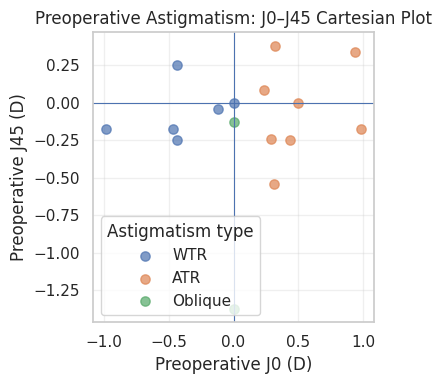

In [316]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Calculate preoperative astigmatism axis
# --------------------------------------------------
df['preop_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['preop_J45'], df['preop_J0'])
    )
) % 180


# --------------------------------------------------
# 2. Classify astigmatism
# --------------------------------------------------
def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan

    if axis <= 30 or axis >= 150:
        return 'ATR'
    elif 60 <= axis <= 120:
        return 'WTR'
    else:
        return 'Oblique'


df['preop_astigmatism_type'] = df['preop_vector_axis'].apply(
    classify_astigmatism
)


# --------------------------------------------------
# 3. Cartesian plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 4))

for category in ['WTR', 'ATR', 'Oblique']:

    subset = df[df['preop_astigmatism_type'] == category]

    ax.scatter(
        subset['preop_J0'],
        subset['preop_J45'],
        label=category,
        alpha=0.7,
        s=45
    )


# Reference axes
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

# Labels
ax.set_xlabel('Preoperative J0 (D)')
ax.set_ylabel('Preoperative J45 (D)')
ax.set_title('Preoperative Astigmatism: J0–J45 Cartesian Plot')

ax.legend(title='Astigmatism type')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [317]:
centroid_J0 = df['preop_J0'].mean()
centroid_J45 = df['preop_J45'].mean()

ax.scatter(
    centroid_J0,
    centroid_J45,
    marker='X',
    s=150,
    label='Centroid'
)

Pre-op centroid J0  = 0.098 D
Pre-op centroid J45 = -0.143 D


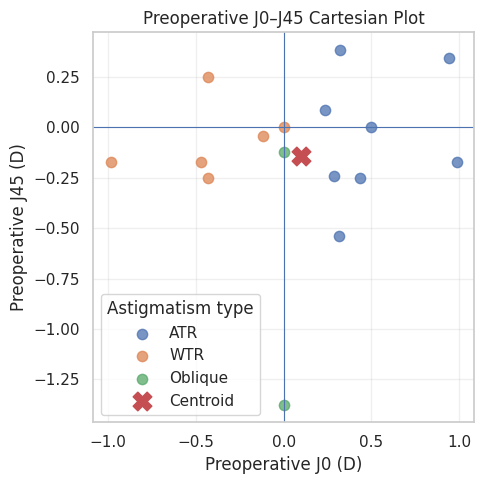

In [318]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Preoperative astigmatism axis
# -----------------------------------------
df['preop_axis'] = (
    0.5 * np.degrees(
        np.arctan2(df['preop_J45'], df['preop_J0'])
    )
) % 180


# -----------------------------------------
# 2. Classify astigmatism
# -----------------------------------------
def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan

    if axis <= 30 or axis >= 150:
        return 'ATR'
    elif 60 <= axis <= 120:
        return 'WTR'
    else:
        return 'Oblique'


df['preop_astigmatism_type'] = df['preop_axis'].apply(
    classify_astigmatism
)


# -----------------------------------------
# 3. Calculate centroid
# -----------------------------------------
centroid_J0 = df['preop_J0'].mean()
centroid_J45 = df['preop_J45'].mean()

print(f"Pre-op centroid J0  = {centroid_J0:.3f} D")
print(f"Pre-op centroid J45 = {centroid_J45:.3f} D")


# -----------------------------------------
# 4. Cartesian plot
# -----------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

for category in ['ATR', 'WTR', 'Oblique']:

    subset = df[df['preop_astigmatism_type'] == category]

    ax.scatter(
        subset['preop_J0'],
        subset['preop_J45'],
        s=55,
        alpha=0.75,
        label=category
    )


# Centroid
ax.scatter(
    centroid_J0,
    centroid_J45,
    marker='X',
    s=180,
    label='Centroid'
)


# Reference axes
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

# Labels
ax.set_xlabel('Preoperative J0 (D)')
ax.set_ylabel('Preoperative J45 (D)')
ax.set_title('Preoperative J0–J45 Cartesian Plot')

ax.legend(title='Astigmatism type')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [319]:
print(df[
    ['preop R1', 'preop R2', 'preop A1',
     'preop_cyl', 'preop_J0', 'preop_J45',
     'preop_axis', 'preop_astigmatism_type']
].head(20))

    preop R1  preop R2  preop A1  preop_cyl      preop_J0     preop_J45  \
0      43.75     43.75       180       0.00 -0.000000e+00  0.000000e+00   
1      45.25     47.25        85       2.00  9.848078e-01 -1.736482e-01   
2      45.75     46.75       115       1.00  3.213938e-01  3.830222e-01   
3      44.25     45.25        90       1.00  5.000000e-01 -6.123234e-17   
4      41.75     43.75       100       2.00  9.396926e-01  3.420201e-01   
5      45.75     47.75         5       2.00 -9.848078e-01 -1.736482e-01   
6      42.00     44.75        45       2.75 -8.419447e-17 -1.375000e+00   
7      43.50     43.75        10       0.25 -1.174616e-01 -4.275252e-02   
8      44.00     45.00       165       1.00 -4.330127e-01  2.500000e-01   
9      47.75     48.75        10       1.00 -4.698463e-01 -1.710101e-01   
10     43.75     44.00        45       0.25 -7.654042e-18 -1.250000e-01   
11     42.25     43.50        60       1.25  3.125000e-01 -5.412659e-01   
12     43.75     44.50   


Preoperative astigmatism classification
                        Count  Percentage
preop_astigmatism_type                   
ATR                         6        37.5
WTR                         8        50.0
Oblique                     2        12.5

Preoperative centroid
J0        = 0.098 D
J45       = -0.143 D
Magnitude = 0.173 D
Axis      = 152.3°


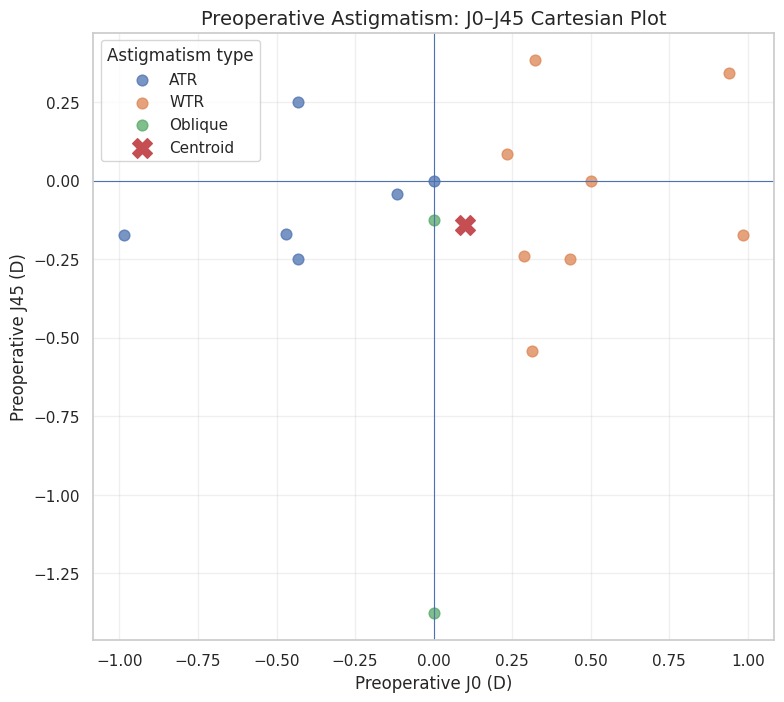


Individual preoperative data
 preop R1  preop R2  preop A1  preop_cyl      preop_J0     preop_J45  preop_J  preop_vector_axis preop_astigmatism_type
    43.75     43.75       180       0.00 -0.000000e+00  0.000000e+00    0.000               90.0                    ATR
    45.25     47.25        85       2.00  9.848078e-01 -1.736482e-01    1.000              175.0                    WTR
    45.75     46.75       115       1.00  3.213938e-01  3.830222e-01    0.500               25.0                    WTR
    44.25     45.25        90       1.00  5.000000e-01 -6.123234e-17    0.500              180.0                    WTR
    41.75     43.75       100       2.00  9.396926e-01  3.420201e-01    1.000               10.0                    WTR
    45.75     47.75         5       2.00 -9.848078e-01 -1.736482e-01    1.000               95.0                    ATR
    42.00     44.75        45       2.75 -8.419447e-17 -1.375000e+00    1.375              135.0                Oblique
    43.50 

In [320]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Calculate preoperative cylinder
# ============================================================

df['preop_cyl'] = df['preop R2'] - df['preop R1']


# ============================================================
# 2. Calculate Thibos J0 and J45
# ============================================================

theta = np.deg2rad(df['preop A1'])

df['preop_J0'] = (
    -(df['preop_cyl'] / 2) *
    np.cos(2 * theta)
)

df['preop_J45'] = (
    -(df['preop_cyl'] / 2) *
    np.sin(2 * theta)
)


# ============================================================
# 3. Calculate vector magnitude
# ============================================================

df['preop_J'] = np.sqrt(
    df['preop_J0']**2 +
    df['preop_J45']**2
)


# ============================================================
# 4. Calculate vector axis
# ============================================================

df['preop_vector_axis'] = (
    0.5 *
    np.degrees(
        np.arctan2(
            df['preop_J45'],
            df['preop_J0']
        )
    )
) % 180


# ============================================================
# 5. WTR / ATR / Oblique classification
#    Based on the clinical cylinder axis
#
#    Since A1 in your data corresponds to the
#    reference meridian, use A1 directly for
#    the clinical axis classification.
# ============================================================

def classify_astigmatism(axis):

    if pd.isna(axis):
        return np.nan

    axis = axis % 180

    if axis <= 30 or axis >= 150:
        return 'ATR'

    elif 60 <= axis <= 120:
        return 'WTR'

    else:
        return 'Oblique'


df['preop_astigmatism_type'] = (
    df['preop A1']
    .apply(classify_astigmatism)
)


# ============================================================
# 6. Display classification
# ============================================================

classification = (
    df['preop_astigmatism_type']
    .value_counts()
    .reindex(
        ['ATR', 'WTR', 'Oblique'],
        fill_value=0
    )
)

percentage = (
    classification /
    classification.sum() *
    100
).round(1)

summary = pd.DataFrame({
    'Count': classification,
    'Percentage': percentage
})

print("\nPreoperative astigmatism classification")
print(summary)


# ============================================================
# 7. Calculate centroid
# ============================================================

centroid_J0 = df['preop_J0'].mean()
centroid_J45 = df['preop_J45'].mean()

centroid_magnitude = np.sqrt(
    centroid_J0**2 +
    centroid_J45**2
)

centroid_axis = (
    0.5 *
    np.degrees(
        np.arctan2(
            centroid_J45,
            centroid_J0
        )
    )
) % 180

print("\nPreoperative centroid")
print(f"J0        = {centroid_J0:.3f} D")
print(f"J45       = {centroid_J45:.3f} D")
print(f"Magnitude = {centroid_magnitude:.3f} D")
print(f"Axis      = {centroid_axis:.1f}°")


# ============================================================
# 8. Cartesian J0–J45 plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

categories = ['ATR', 'WTR', 'Oblique']

for category in categories:

    subset = df[
        df['preop_astigmatism_type'] == category
    ]

    ax.scatter(
        subset['preop_J0'],
        subset['preop_J45'],
        s=60,
        alpha=0.75,
        label=category
    )


# ============================================================
# 9. Plot centroid
# ============================================================

ax.scatter(
    centroid_J0,
    centroid_J45,
    marker='X',
    s=200,
    label='Centroid'
)


# ============================================================
# 10. Reference axes
# ============================================================

ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)


# ============================================================
# 11. Labels and formatting
# ============================================================

ax.set_xlabel(
    'Preoperative J0 (D)',
    fontsize=12
)

ax.set_ylabel(
    'Preoperative J45 (D)',
    fontsize=12
)

ax.set_title(
    'Preoperative Astigmatism: J0–J45 Cartesian Plot',
    fontsize=14
)

ax.legend(
    title='Astigmatism type'
)

ax.grid(
    True,
    alpha=0.3
)

ax.set_aspect(
    'equal',
    adjustable='box'
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Show individual data with classification
# ============================================================

output = df[
    [
        'preop R1',
        'preop R2',
        'preop A1',
        'preop_cyl',
        'preop_J0',
        'preop_J45',
        'preop_J',
        'preop_vector_axis',
        'preop_astigmatism_type'
    ]
]

print("\nIndividual preoperative data")
print(output.to_string(index=False))


Postoperative astigmatism classification
                         Count  Percentage
postop_astigmatism_type                   
ATR                          5        31.2
WTR                         10        62.5
Oblique                      1         6.2

Postoperative centroid
J0        = 0.203 D
J45       = 0.031 D
Magnitude = 0.205 D
Axis      = 4.4°


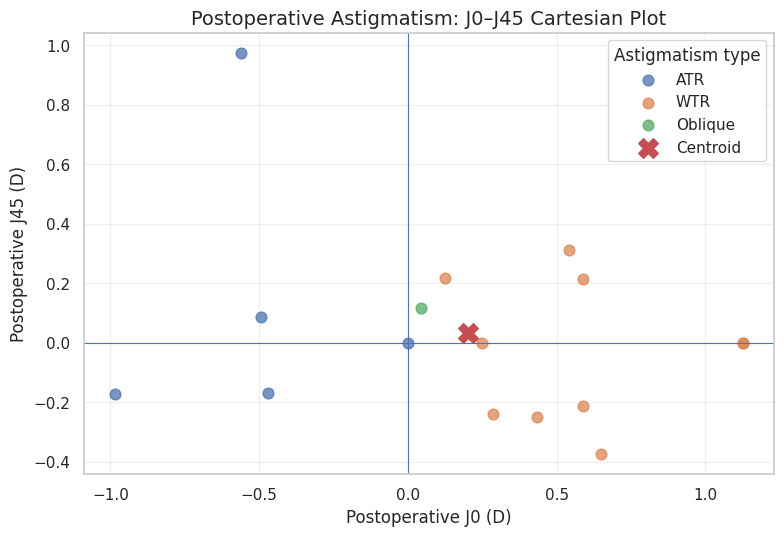

In [321]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Postoperative cylinder
# ============================================================

df['postop_cyl'] = (
    df['postop 1wk R2'] - df['postop 1wk R1']
)


# ============================================================
# 2. Thibos J0 and J45
# ============================================================

theta = np.deg2rad(df['postop 1wk A1'])

df['postop_J0'] = (
    -(df['postop_cyl'] / 2) *
    np.cos(2 * theta)
)

df['postop_J45'] = (
    -(df['postop_cyl'] / 2) *
    np.sin(2 * theta)
)


# ============================================================
# 3. Vector magnitude
# ============================================================

df['postop_J'] = np.sqrt(
    df['postop_J0']**2 +
    df['postop_J45']**2
)


# ============================================================
# 4. Vector axis
# ============================================================

df['postop_vector_axis'] = (
    0.5 *
    np.degrees(
        np.arctan2(
            df['postop_J45'],
            df['postop_J0']
        )
    )
) % 180


# ============================================================
# 5. WTR / ATR / Oblique classification
# ============================================================

def classify_astigmatism(axis):

    if pd.isna(axis):
        return np.nan

    axis = axis % 180

    if axis <= 30 or axis >= 150:
        return 'ATR'

    elif 60 <= axis <= 120:
        return 'WTR'

    else:
        return 'Oblique'


df['postop_astigmatism_type'] = (
    df['postop 1wk A1']
    .apply(classify_astigmatism)
)


# ============================================================
# 6. Count and percentage
# ============================================================

classification = (
    df['postop_astigmatism_type']
    .value_counts()
    .reindex(
        ['ATR', 'WTR', 'Oblique'],
        fill_value=0
    )
)

percentage = (
    classification /
    classification.sum() *
    100
).round(1)

postop_summary = pd.DataFrame({
    'Count': classification,
    'Percentage': percentage
})

print("\nPostoperative astigmatism classification")
print(postop_summary)


# ============================================================
# 7. Postoperative centroid
# ============================================================

centroid_J0 = df['postop_J0'].mean()
centroid_J45 = df['postop_J45'].mean()

centroid_magnitude = np.sqrt(
    centroid_J0**2 +
    centroid_J45**2
)

centroid_axis = (
    0.5 *
    np.degrees(
        np.arctan2(
            centroid_J45,
            centroid_J0
        )
    )
) % 180

print("\nPostoperative centroid")
print(f"J0        = {centroid_J0:.3f} D")
print(f"J45       = {centroid_J45:.3f} D")
print(f"Magnitude = {centroid_magnitude:.3f} D")
print(f"Axis      = {centroid_axis:.1f}°")


# ============================================================
# 8. Cartesian plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

for category in ['ATR', 'WTR', 'Oblique']:

    subset = df[
        df['postop_astigmatism_type'] == category
    ]

    ax.scatter(
        subset['postop_J0'],
        subset['postop_J45'],
        s=60,
        alpha=0.75,
        label=category
    )


# Centroid
ax.scatter(
    centroid_J0,
    centroid_J45,
    marker='X',
    s=200,
    label='Centroid'
)


# Reference axes
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)


# Labels
ax.set_xlabel(
    'Postoperative J0 (D)',
    fontsize=12
)

ax.set_ylabel(
    'Postoperative J45 (D)',
    fontsize=12
)

ax.set_title(
    'Postoperative Astigmatism: J0–J45 Cartesian Plot',
    fontsize=14
)

ax.legend(title='Astigmatism type')

ax.grid(True, alpha=0.3)

ax.set_aspect(
    'equal',
    adjustable='box'
)

plt.tight_layout()
plt.show()

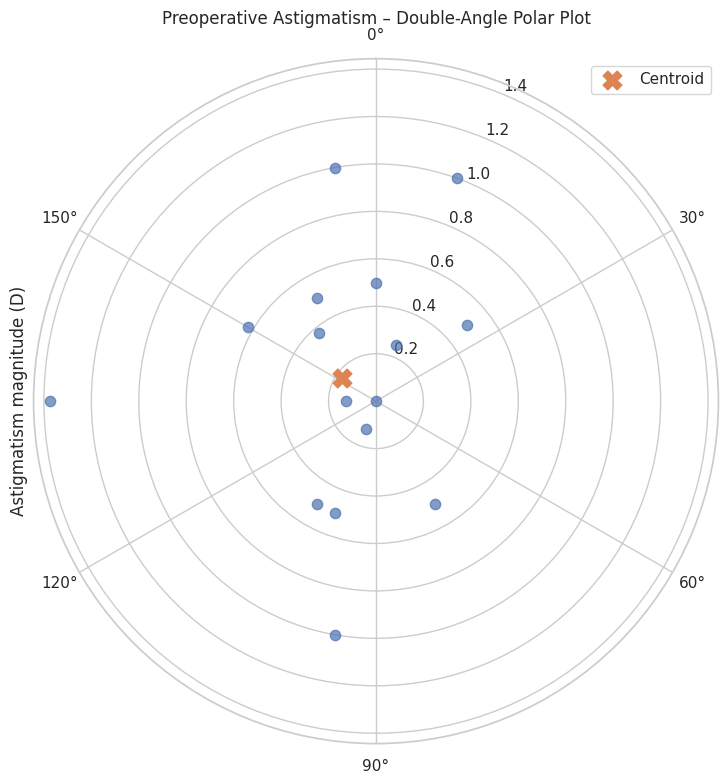

In [322]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Preoperative magnitude and clinical axis
# --------------------------------------------------

preop_J = np.sqrt(
    df['preop_J0']**2 +
    df['preop_J45']**2
)

preop_axis = (
    0.5 * np.degrees(
        np.arctan2(
            df['preop_J45'],
            df['preop_J0']
        )
    )
) % 180

# Double angle for polar plot
theta_preop = np.deg2rad(2 * preop_axis)


# --------------------------------------------------
# Centroid
# --------------------------------------------------

centroid_J0 = df['preop_J0'].mean()
centroid_J45 = df['preop_J45'].mean()

centroid_J = np.sqrt(
    centroid_J0**2 +
    centroid_J45**2
)

centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(
            centroid_J45,
            centroid_J0
        )
    )
) % 180

theta_centroid = np.deg2rad(2 * centroid_axis)


# --------------------------------------------------
# Polar plot
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': 'polar'}
)

ax.scatter(
    theta_preop,
    preop_J,
    s=55,
    alpha=0.7
)

# Centroid
ax.scatter(
    theta_centroid,
    centroid_J,
    marker='X',
    s=180,
    label='Centroid'
)


# --------------------------------------------------
# Orientation
# --------------------------------------------------

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# Clinical axis labels
clinical_axes = np.arange(0, 180, 30)

ax.set_xticks(
    np.deg2rad(2 * clinical_axes)
)

ax.set_xticklabels(
    [f'{x}°' for x in clinical_axes]
)

ax.set_title(
    'Preoperative Astigmatism – Double-Angle Polar Plot',
    pad=25
)

ax.set_ylabel('Astigmatism magnitude (D)')

ax.legend()

plt.tight_layout()
plt.show()

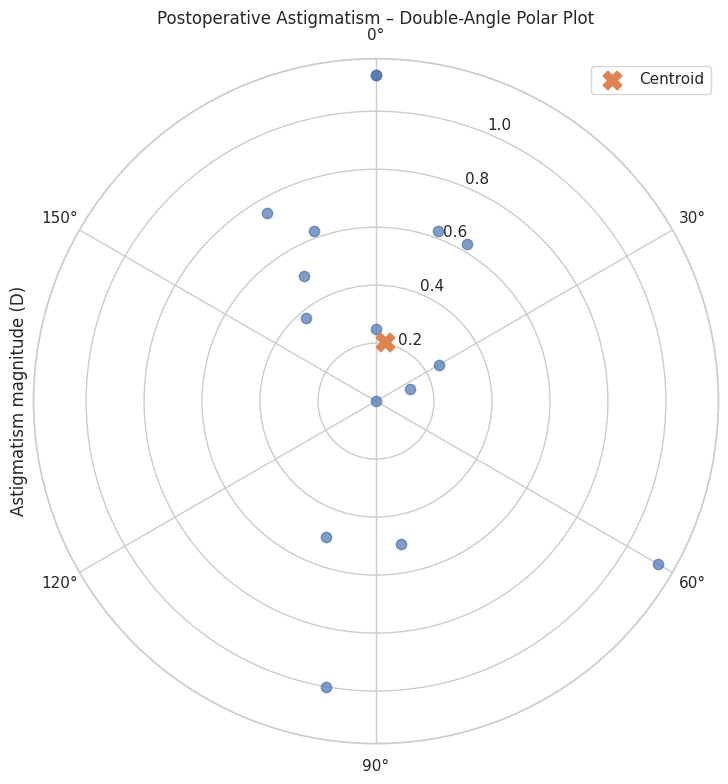

In [323]:
postop_J = np.sqrt(
    df['postop_J0']**2 +
    df['postop_J45']**2
)

postop_axis = (
    0.5 * np.degrees(
        np.arctan2(
            df['postop_J45'],
            df['postop_J0']
        )
    )
) % 180

theta_postop = np.deg2rad(2 * postop_axis)

centroid_J0 = df['postop_J0'].mean()
centroid_J45 = df['postop_J45'].mean()

centroid_J = np.sqrt(
    centroid_J0**2 +
    centroid_J45**2
)

centroid_axis = (
    0.5 * np.degrees(
        np.arctan2(
            centroid_J45,
            centroid_J0
        )
    )
) % 180

theta_centroid = np.deg2rad(2 * centroid_axis)


fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': 'polar'}
)

ax.scatter(
    theta_postop,
    postop_J,
    s=55,
    alpha=0.7
)

ax.scatter(
    theta_centroid,
    centroid_J,
    marker='X',
    s=180,
    label='Centroid'
)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

clinical_axes = np.arange(0, 180, 30)

ax.set_xticks(
    np.deg2rad(2 * clinical_axes)
)

ax.set_xticklabels(
    [f'{x}°' for x in clinical_axes]
)

ax.set_title(
    'Postoperative Astigmatism – Double-Angle Polar Plot',
    pad=25
)

ax.set_ylabel('Astigmatism magnitude (D)')

ax.legend()

plt.tight_layout()
plt.show()

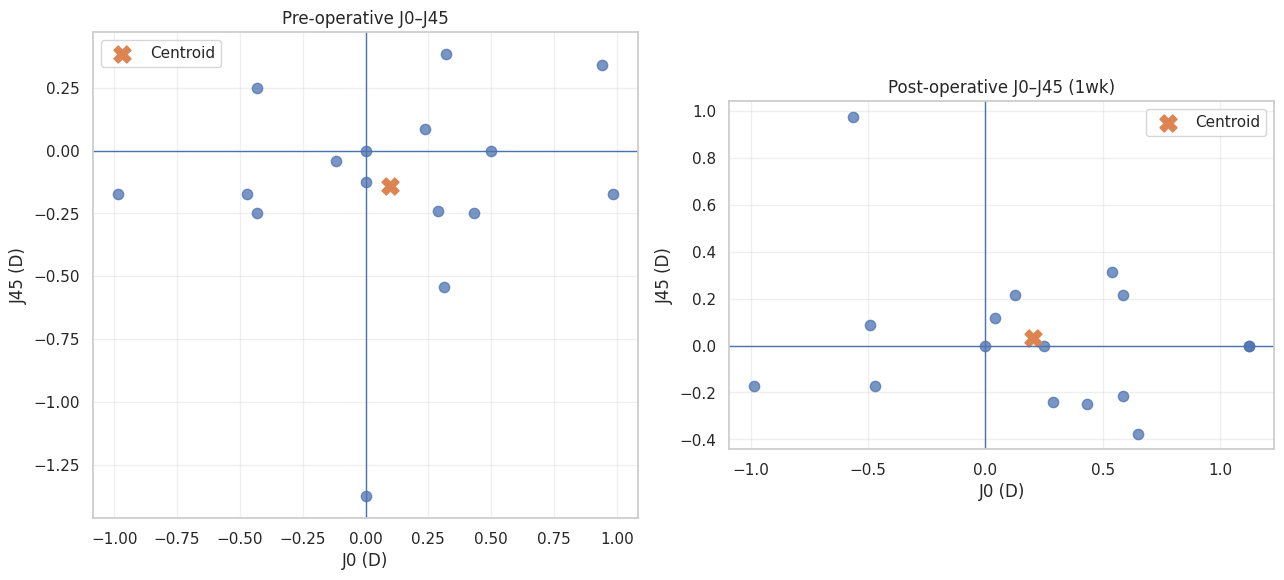

In [324]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. FUNCTION TO CALCULATE J0 AND J45
# ---------------------------------------------------------
def calculate_J_components(R1, R2, axis):
    cyl = R2 - R1
    theta = np.deg2rad(axis)

    J0 = -(cyl / 2) * np.cos(2 * theta)
    J45 = -(cyl / 2) * np.sin(2 * theta)

    return J0, J45


# ---------------------------------------------------------
# 2. PRE-OPERATIVE J0 AND J45
# ---------------------------------------------------------
df['preop_cyl'] = df['preop R2'] - df['preop R1']

df['preop_J0'], df['preop_J45'] = calculate_J_components(
    df['preop R1'],
    df['preop R2'],
    df['preop A1']
)


# ---------------------------------------------------------
# 3. POST-OPERATIVE J0 AND J45
#    Change "1wk" to "6wk" or "3mo" as required
# ---------------------------------------------------------
postop_time = "1wk"

df['postop_cyl'] = (
    df[f'postop {postop_time} R2'] -
    df[f'postop {postop_time} R1']
)

df['postop_J0'], df['postop_J45'] = calculate_J_components(
    df[f'postop {postop_time} R1'],
    df[f'postop {postop_time} R2'],
    df[f'postop {postop_time} A1']
)


# ---------------------------------------------------------
# 4. CARTESIAN PLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# =========================
# PRE-OP
# =========================
ax = axes[0]

ax.scatter(
    df['preop_J0'],
    df['preop_J45'],
    s=55,
    alpha=0.75
)

# Origin
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

# Centroid
preop_centroid_J0 = df['preop_J0'].mean()
preop_centroid_J45 = df['preop_J45'].mean()

ax.scatter(
    preop_centroid_J0,
    preop_centroid_J45,
    marker='X',
    s=150,
    label='Centroid'
)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Pre-operative J0–J45')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


# =========================
# POST-OP
# =========================
ax = axes[1]

ax.scatter(
    df['postop_J0'],
    df['postop_J45'],
    s=55,
    alpha=0.75
)

# Origin
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

# Centroid
postop_centroid_J0 = df['postop_J0'].mean()
postop_centroid_J45 = df['postop_J45'].mean()

ax.scatter(
    postop_centroid_J0,
    postop_centroid_J45,
    marker='X',
    s=150,
    label='Centroid'
)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title(f'Post-operative J0–J45 ({postop_time})')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


plt.tight_layout()
plt.show()

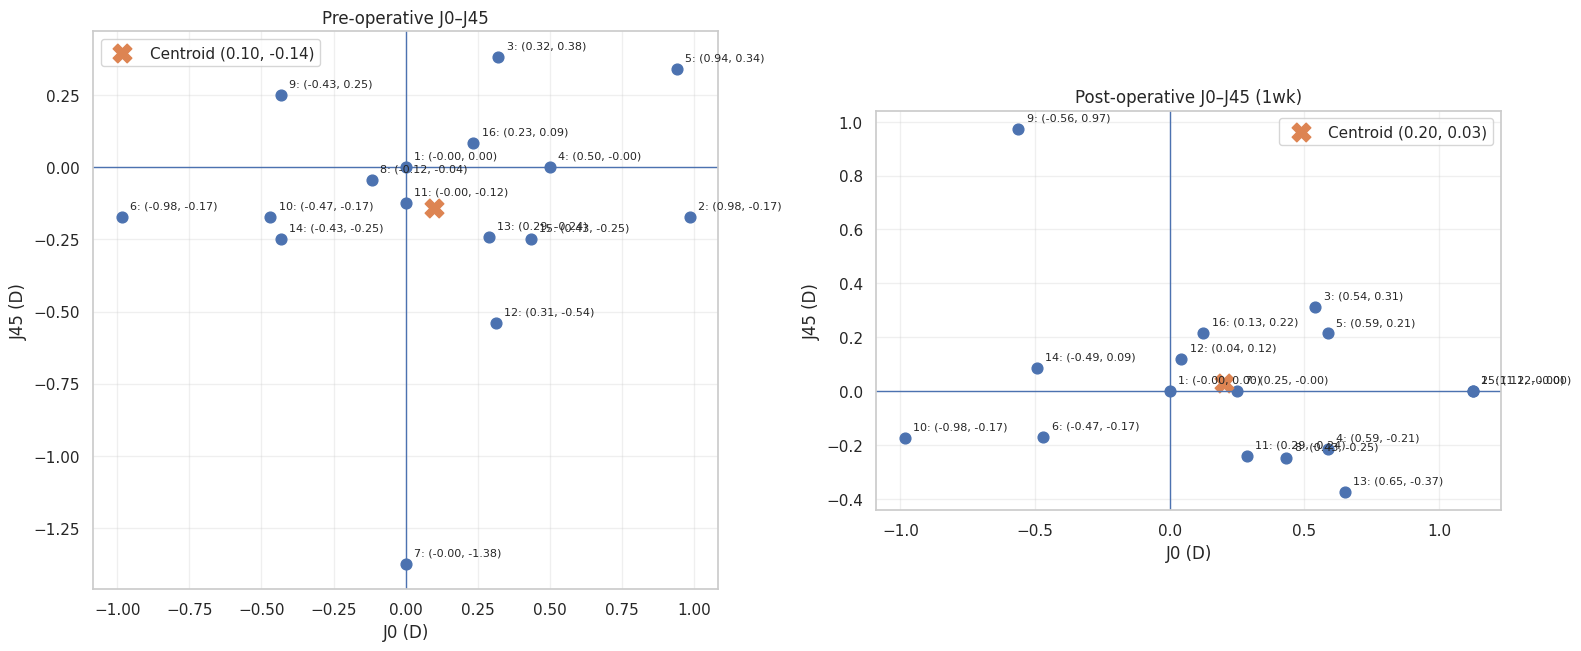

In [325]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# FUNCTION TO CALCULATE J0 AND J45
# ---------------------------------------------------------
def calculate_J_components(R1, R2, axis):
    cyl = R2 - R1
    theta = np.deg2rad(axis)

    J0 = -(cyl / 2) * np.cos(2 * theta)
    J45 = -(cyl / 2) * np.sin(2 * theta)

    return J0, J45


# ---------------------------------------------------------
# PRE-OP
# ---------------------------------------------------------
df['preop_J0'], df['preop_J45'] = calculate_J_components(
    df['preop R1'],
    df['preop R2'],
    df['preop A1']
)


# ---------------------------------------------------------
# POST-OP: CHANGE TIME HERE
# ---------------------------------------------------------
postop_time = "1wk"

df['postop_J0'], df['postop_J45'] = calculate_J_components(
    df[f'postop {postop_time} R1'],
    df[f'postop {postop_time} R2'],
    df[f'postop {postop_time} A1']
)


# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# =========================================================
# PRE-OP
# =========================================================
ax = axes[0]

x = df['preop_J0']
y = df['preop_J45']

ax.scatter(x, y, s=60)

# Label every point
for i, (xi, yi) in enumerate(zip(x, y), start=1):
    ax.annotate(
        f'{i}: ({xi:.2f}, {yi:.2f})',
        (xi, yi),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=8
    )

# Centroid
cx = x.mean()
cy = y.mean()

ax.scatter(
    cx, cy,
    marker='X',
    s=180,
    label=f'Centroid ({cx:.2f}, {cy:.2f})'
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Pre-operative J0–J45')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


# =========================================================
# POST-OP
# =========================================================
ax = axes[1]

x = df['postop_J0']
y = df['postop_J45']

ax.scatter(x, y, s=60)

# Label every point
for i, (xi, yi) in enumerate(zip(x, y), start=1):
    ax.annotate(
        f'{i}: ({xi:.2f}, {yi:.2f})',
        (xi, yi),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=8
    )

# Centroid
cx = x.mean()
cy = y.mean()

ax.scatter(
    cx, cy,
    marker='X',
    s=180,
    label=f'Centroid ({cx:.2f}, {cy:.2f})'
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title(f'Post-operative J0–J45 ({postop_time})')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


plt.tight_layout()
plt.show()

PRE-OP
Mean J0  = 0.098 D
Mean J45 = -0.143 D

POST-OP
Mean J0  = 0.203 D
Mean J45 = 0.031 D


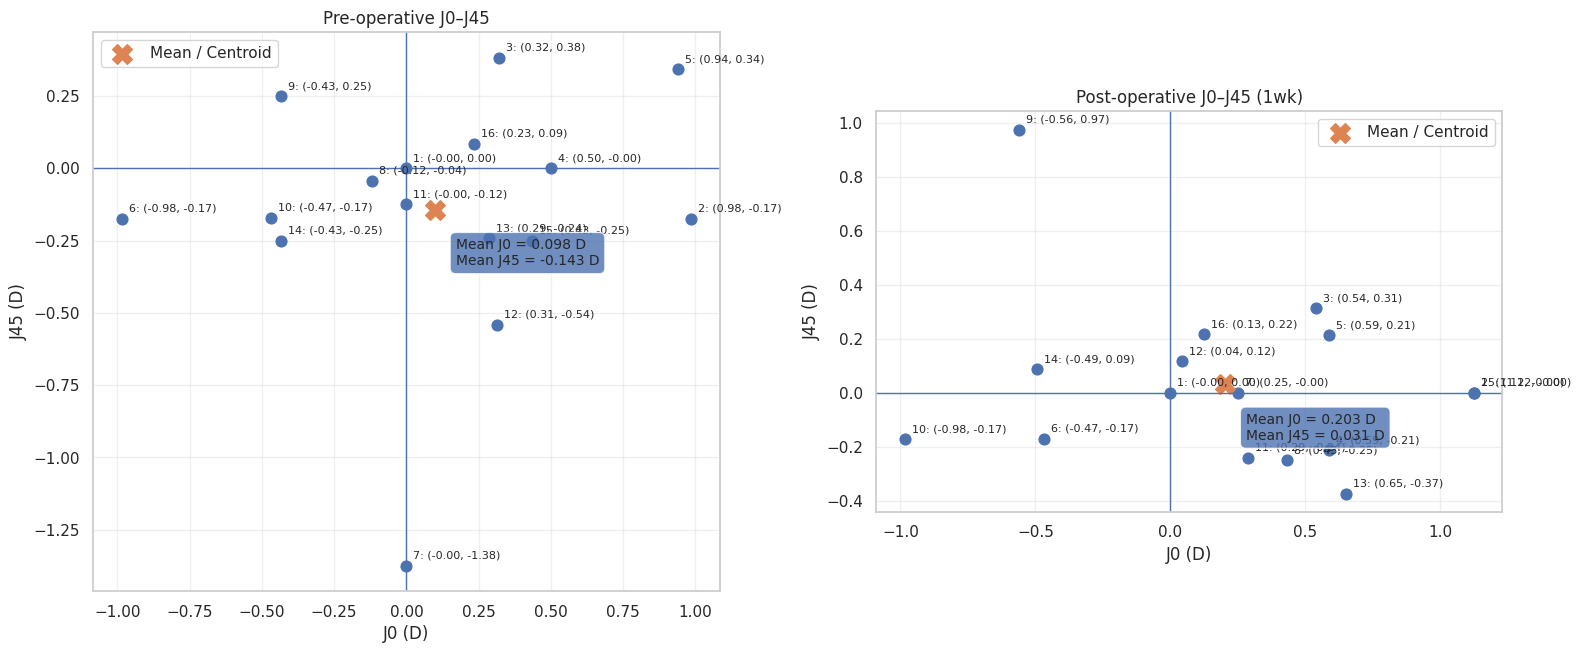

In [326]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# FUNCTION TO CALCULATE J0 AND J45
# ---------------------------------------------------------
def calculate_J_components(R1, R2, axis):
    cyl = R2 - R1
    theta = np.deg2rad(axis)

    J0 = -(cyl / 2) * np.cos(2 * theta)
    J45 = -(cyl / 2) * np.sin(2 * theta)

    return J0, J45


# ---------------------------------------------------------
# PRE-OP
# ---------------------------------------------------------
df['preop_J0'], df['preop_J45'] = calculate_J_components(
    df['preop R1'],
    df['preop R2'],
    df['preop A1']
)


# ---------------------------------------------------------
# POST-OP
# ---------------------------------------------------------
postop_time = "1wk"

df['postop_J0'], df['postop_J45'] = calculate_J_components(
    df[f'postop {postop_time} R1'],
    df[f'postop {postop_time} R2'],
    df[f'postop {postop_time} A1']
)


# ---------------------------------------------------------
# MEAN J0 AND J45
# ---------------------------------------------------------
preop_mean_J0 = df['preop_J0'].mean()
preop_mean_J45 = df['preop_J45'].mean()

postop_mean_J0 = df['postop_J0'].mean()
postop_mean_J45 = df['postop_J45'].mean()


print("PRE-OP")
print(f"Mean J0  = {preop_mean_J0:.3f} D")
print(f"Mean J45 = {preop_mean_J45:.3f} D")

print("\nPOST-OP")
print(f"Mean J0  = {postop_mean_J0:.3f} D")
print(f"Mean J45 = {postop_mean_J45:.3f} D")


# ---------------------------------------------------------
# CARTESIAN PLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# =========================================================
# PRE-OP
# =========================================================
ax = axes[0]

x = df['preop_J0']
y = df['preop_J45']

ax.scatter(x, y, s=60)

# Label individual values
for i, (xi, yi) in enumerate(zip(x, y), start=1):
    ax.annotate(
        f'{i}: ({xi:.2f}, {yi:.2f})',
        (xi, yi),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

# Mean / centroid
ax.scatter(
    preop_mean_J0,
    preop_mean_J45,
    marker='X',
    s=200,
    label='Mean / Centroid'
)

# Display mean values on graph
ax.annotate(
    f'Mean J0 = {preop_mean_J0:.3f} D\n'
    f'Mean J45 = {preop_mean_J45:.3f} D',
    (preop_mean_J0, preop_mean_J45),
    xytext=(15, -40),
    textcoords='offset points',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.8)
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Pre-operative J0–J45')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


# =========================================================
# POST-OP
# =========================================================
ax = axes[1]

x = df['postop_J0']
y = df['postop_J45']

ax.scatter(x, y, s=60)

# Label individual values
for i, (xi, yi) in enumerate(zip(x, y), start=1):
    ax.annotate(
        f'{i}: ({xi:.2f}, {yi:.2f})',
        (xi, yi),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

# Mean / centroid
ax.scatter(
    postop_mean_J0,
    postop_mean_J45,
    marker='X',
    s=200,
    label='Mean / Centroid'
)

# Display mean values
ax.annotate(
    f'Mean J0 = {postop_mean_J0:.3f} D\n'
    f'Mean J45 = {postop_mean_J45:.3f} D',
    (postop_mean_J0, postop_mean_J45),
    xytext=(15, -40),
    textcoords='offset points',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.8)
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title(f'Post-operative J0–J45 ({postop_time})')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


plt.tight_layout()
plt.show()

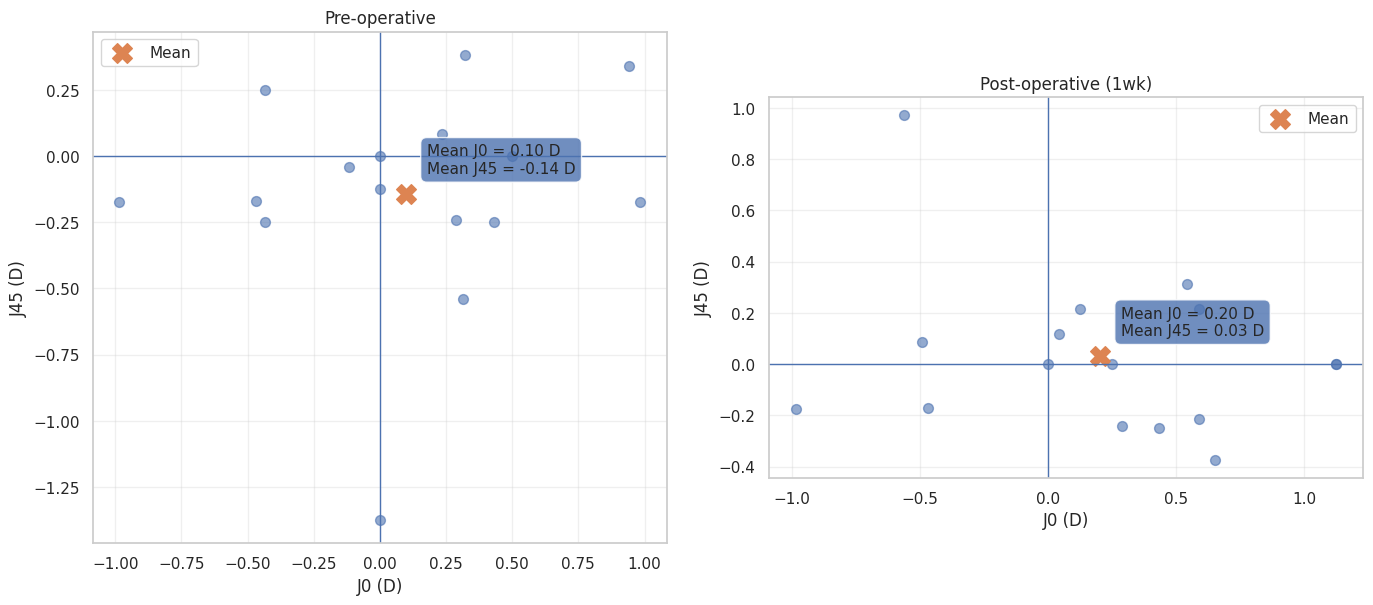

In [327]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# FUNCTION TO CALCULATE J0 AND J45
# ---------------------------------------------------------
def calculate_J_components(R1, R2, axis):
    cyl = R2 - R1
    theta = np.deg2rad(axis)

    J0 = -(cyl / 2) * np.cos(2 * theta)
    J45 = -(cyl / 2) * np.sin(2 * theta)

    return J0, J45


# ---------------------------------------------------------
# PRE-OP
# ---------------------------------------------------------
df['preop_J0'], df['preop_J45'] = calculate_J_components(
    df['preop R1'],
    df['preop R2'],
    df['preop A1']
)


# ---------------------------------------------------------
# POST-OP
# ---------------------------------------------------------
postop_time = "1wk"

df['postop_J0'], df['postop_J45'] = calculate_J_components(
    df[f'postop {postop_time} R1'],
    df[f'postop {postop_time} R2'],
    df[f'postop {postop_time} A1']
)


# ---------------------------------------------------------
# MEANS
# ---------------------------------------------------------
preop_J0_mean = df['preop_J0'].mean()
preop_J45_mean = df['preop_J45'].mean()

postop_J0_mean = df['postop_J0'].mean()
postop_J45_mean = df['postop_J45'].mean()


# ---------------------------------------------------------
# CARTESIAN PLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# =========================================================
# PRE-OP
# =========================================================
ax = axes[0]

ax.scatter(
    df['preop_J0'],
    df['preop_J45'],
    s=50,
    alpha=0.6
)

# Mean point ONLY
ax.scatter(
    preop_J0_mean,
    preop_J45_mean,
    marker='X',
    s=200,
    label='Mean'
)

# Mean values displayed once
ax.annotate(
    f'Mean J0 = {preop_J0_mean:.2f} D\n'
    f'Mean J45 = {preop_J45_mean:.2f} D',
    xy=(preop_J0_mean, preop_J45_mean),
    xytext=(15, 15),
    textcoords='offset points',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.8)
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Pre-operative')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()


# =========================================================
# POST-OP
# =========================================================
ax = axes[1]

ax.scatter(
    df['postop_J0'],
    df['postop_J45'],
    s=50,
    alpha=0.6
)

# Mean point ONLY
ax.scatter(
    postop_J0_mean,
    postop_J45_mean,
    marker='X',
    s=200,
    label='Mean'
)

# Mean values displayed once
ax.annotate(
    f'Mean J0 = {postop_J0_mean:.2f} D\n'
    f'Mean J45 = {postop_J45_mean:.2f} D',
    xy=(postop_J0_mean, postop_J45_mean),
    xytext=(15, 15),
    textcoords='offset points',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.8)
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title(f'Post-operative ({postop_time})')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()

plt.tight_layout()
plt.show()

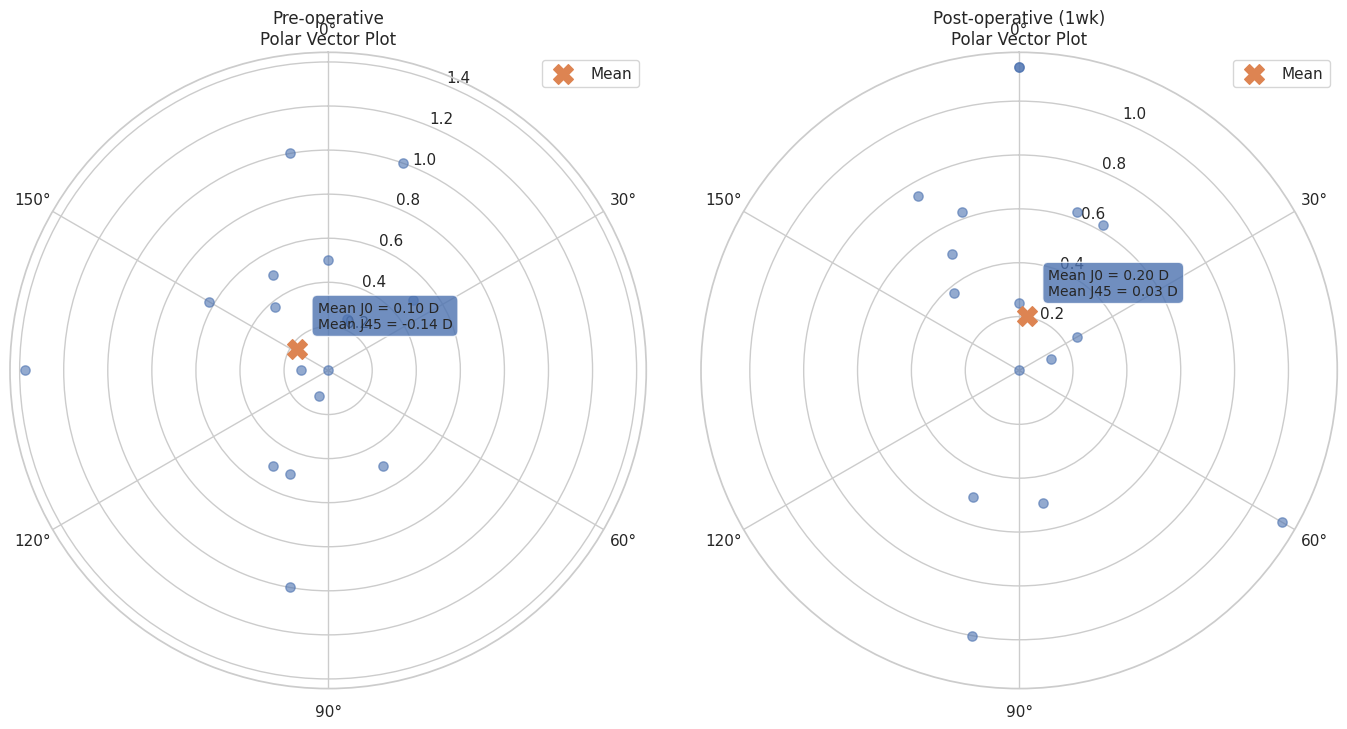

In [328]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# FUNCTION TO CALCULATE J0 AND J45
# ---------------------------------------------------------
def calculate_J_components(R1, R2, axis):
    cyl = R2 - R1
    theta = np.deg2rad(axis)

    J0 = -(cyl / 2) * np.cos(2 * theta)
    J45 = -(cyl / 2) * np.sin(2 * theta)

    return J0, J45


# ---------------------------------------------------------
# PRE-OP
# ---------------------------------------------------------
df['preop_J0'], df['preop_J45'] = calculate_J_components(
    df['preop R1'],
    df['preop R2'],
    df['preop A1']
)


# ---------------------------------------------------------
# POST-OP
# ---------------------------------------------------------
postop_time = "1wk"

df['postop_J0'], df['postop_J45'] = calculate_J_components(
    df[f'postop {postop_time} R1'],
    df[f'postop {postop_time} R2'],
    df[f'postop {postop_time} A1']
)


# =========================================================
# MEAN J0 AND J45
# =========================================================
preop_mean_J0 = df['preop_J0'].mean()
preop_mean_J45 = df['preop_J45'].mean()

postop_mean_J0 = df['postop_J0'].mean()
postop_mean_J45 = df['postop_J45'].mean()


# ---------------------------------------------------------
# FUNCTION: J0/J45 → MAGNITUDE AND POLAR ANGLE
# ---------------------------------------------------------
def vector_to_polar(J0, J45):
    magnitude = np.sqrt(J0**2 + J45**2)

    axis = (
        0.5 * np.degrees(np.arctan2(J45, J0))
    ) % 180

    theta = np.deg2rad(2 * axis)

    return magnitude, theta


# =========================================================
# PRE-OP POLAR
# =========================================================
preop_J = np.sqrt(
    df['preop_J0']**2 +
    df['preop_J45']**2
)

preop_axis = (
    0.5 * np.degrees(
        np.arctan2(
            df['preop_J45'],
            df['preop_J0']
        )
    )
) % 180

preop_theta = np.deg2rad(2 * preop_axis)


# Mean vector
preop_mean_J, preop_mean_theta = vector_to_polar(
    preop_mean_J0,
    preop_mean_J45
)


# =========================================================
# POST-OP POLAR
# =========================================================
postop_J = np.sqrt(
    df['postop_J0']**2 +
    df['postop_J45']**2
)

postop_axis = (
    0.5 * np.degrees(
        np.arctan2(
            df['postop_J45'],
            df['postop_J0']
        )
    )
) % 180

postop_theta = np.deg2rad(2 * postop_axis)


# Mean vector
postop_mean_J, postop_mean_theta = vector_to_polar(
    postop_mean_J0,
    postop_mean_J45
)


# =========================================================
# PLOTS
# =========================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 7),
    subplot_kw={'projection': 'polar'}
)


# =========================================================
# PRE-OP
# =========================================================
ax = axes[0]

ax.scatter(
    preop_theta,
    preop_J,
    s=45,
    alpha=0.6
)

# Mean vector
ax.scatter(
    preop_mean_theta,
    preop_mean_J,
    marker='X',
    s=200,
    label='Mean'
)

# ONLY mean values displayed
ax.annotate(
    f'Mean J0 = {preop_mean_J0:.2f} D\n'
    f'Mean J45 = {preop_mean_J45:.2f} D',
    xy=(preop_mean_theta, preop_mean_J),
    xytext=(15, 15),
    textcoords='offset points',
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.4',
        alpha=0.8
    )
)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# Clinical axis labels
clinical_axes = np.arange(0, 180, 30)
ax.set_xticks(np.deg2rad(2 * clinical_axes))
ax.set_xticklabels(
    [f'{x}°' for x in clinical_axes]
)

ax.set_title('Pre-operative\nPolar Vector Plot')
ax.legend(loc='upper right')


# =========================================================
# POST-OP
# =========================================================
ax = axes[1]

ax.scatter(
    postop_theta,
    postop_J,
    s=45,
    alpha=0.6
)

# Mean vector
ax.scatter(
    postop_mean_theta,
    postop_mean_J,
    marker='X',
    s=200,
    label='Mean'
)

# ONLY mean values displayed
ax.annotate(
    f'Mean J0 = {postop_mean_J0:.2f} D\n'
    f'Mean J45 = {postop_mean_J45:.2f} D',
    xy=(postop_mean_theta, postop_mean_J),
    xytext=(15, 15),
    textcoords='offset points',
    fontsize=10,
    bbox=dict(
        boxstyle='round,pad=0.4',
        alpha=0.8
    )
)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_xticks(np.deg2rad(2 * clinical_axes))
ax.set_xticklabels(
    [f'{x}°' for x in clinical_axes]
)

ax.set_title(
    f'Post-operative ({postop_time})\nPolar Vector Plot'
)
ax.legend(loc='upper right')


plt.tight_layout()
plt.show()

DELTA CHANGE
Δ J0        = 0.104 D
Δ J45       = 0.174 D
Δ Magnitude = 0.039 D


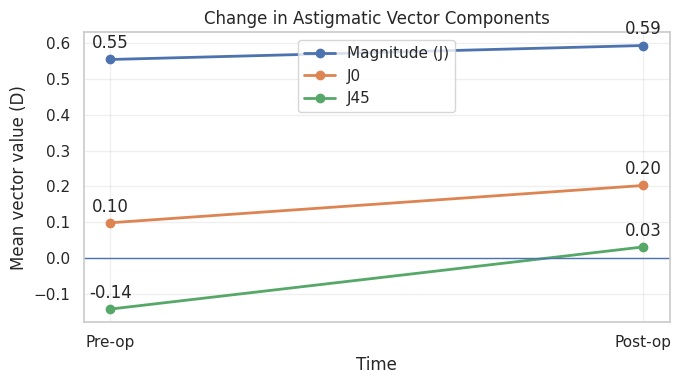

In [329]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CALCULATE J0, J45 AND MAGNITUDE
# ---------------------------------------------------------
def calculate_J_components(R1, R2, axis):
    cyl = R2 - R1
    theta = np.deg2rad(axis)

    J0 = -(cyl / 2) * np.cos(2 * theta)
    J45 = -(cyl / 2) * np.sin(2 * theta)

    return J0, J45


# Pre-op
df['preop_J0'], df['preop_J45'] = calculate_J_components(
    df['preop R1'],
    df['preop R2'],
    df['preop A1']
)

df['preop_magnitude'] = np.sqrt(
    df['preop_J0']**2 +
    df['preop_J45']**2
)


# Post-op
postop_time = "1wk"

df['postop_J0'], df['postop_J45'] = calculate_J_components(
    df[f'postop {postop_time} R1'],
    df[f'postop {postop_time} R2'],
    df[f'postop {postop_time} A1']
)

df['postop_magnitude'] = np.sqrt(
    df['postop_J0']**2 +
    df['postop_J45']**2
)


# ---------------------------------------------------------
# MEAN VALUES
# ---------------------------------------------------------
preop_mean_J0 = df['preop_J0'].mean()
postop_mean_J0 = df['postop_J0'].mean()

preop_mean_J45 = df['preop_J45'].mean()
postop_mean_J45 = df['postop_J45'].mean()

preop_mean_magnitude = df['preop_magnitude'].mean()
postop_mean_magnitude = df['postop_magnitude'].mean()


# ---------------------------------------------------------
# DELTA CHANGE
# ---------------------------------------------------------
delta_J0 = postop_mean_J0 - preop_mean_J0
delta_J45 = postop_mean_J45 - preop_mean_J45
delta_magnitude = postop_mean_magnitude - preop_mean_magnitude


print("DELTA CHANGE")
print(f"Δ J0        = {delta_J0:.3f} D")
print(f"Δ J45       = {delta_J45:.3f} D")
print(f"Δ Magnitude = {delta_magnitude:.3f} D")


# ---------------------------------------------------------
# LINE GRAPH
# ---------------------------------------------------------
time_points = ['Pre-op', 'Post-op']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    time_points,
    [preop_mean_magnitude, postop_mean_magnitude],
    marker='o',
    linewidth=2,
    label='Magnitude (J)'
)

ax.plot(
    time_points,
    [preop_mean_J0, postop_mean_J0],
    marker='o',
    linewidth=2,
    label='J0'
)

ax.plot(
    time_points,
    [preop_mean_J45, postop_mean_J45],
    marker='o',
    linewidth=2,
    label='J45'
)


# ---------------------------------------------------------
# DISPLAY VALUES AT EACH POINT
# ---------------------------------------------------------
ax.annotate(
    f'{preop_mean_magnitude:.2f}',
    ('Pre-op', preop_mean_magnitude),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)

ax.annotate(
    f'{postop_mean_magnitude:.2f}',
    ('Post-op', postop_mean_magnitude),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)

ax.annotate(
    f'{preop_mean_J0:.2f}',
    ('Pre-op', preop_mean_J0),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)

ax.annotate(
    f'{postop_mean_J0:.2f}',
    ('Post-op', postop_mean_J0),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)

ax.annotate(
    f'{preop_mean_J45:.2f}',
    ('Pre-op', preop_mean_J45),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)

ax.annotate(
    f'{postop_mean_J45:.2f}',
    ('Post-op', postop_mean_J45),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center'
)


# ---------------------------------------------------------
# FORMATTING
# ---------------------------------------------------------
ax.axhline(0, linewidth=1)

ax.set_xlabel('Time')
ax.set_ylabel('Mean vector value (D)')
ax.set_title('Change in Astigmatic Vector Components')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

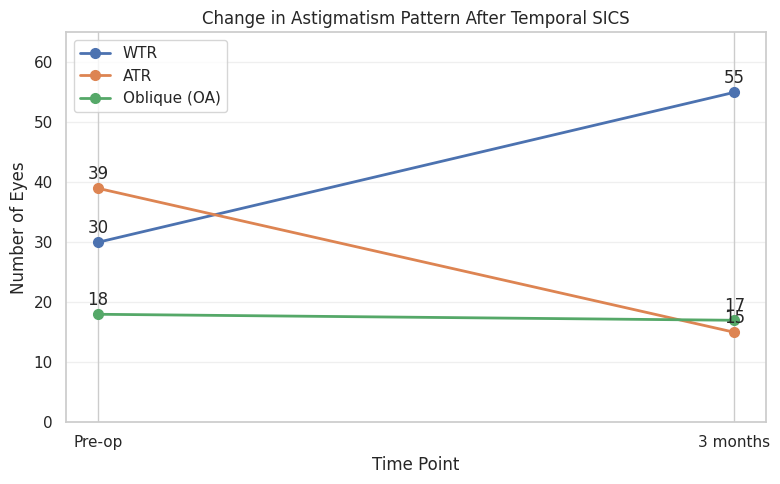

In [330]:
import matplotlib.pyplot as plt
import numpy as np

# Data
time = ['Pre-op', '3 months']

WTR = [30, 55]
ATR = [39, 15]
OA  = [18, 17]

x = np.arange(len(time))

# Plot
plt.figure(figsize=(8, 5))

plt.plot(x, WTR, marker='o', linewidth=2, markersize=7, label='WTR')
plt.plot(x, ATR, marker='o', linewidth=2, markersize=7, label='ATR')
plt.plot(x, OA,  marker='o', linewidth=2, markersize=7, label='Oblique (OA)')

# Display values at each point
for i, value in enumerate(WTR):
    plt.text(x[i], value + 1.5, str(value), ha='center')

for i, value in enumerate(ATR):
    plt.text(x[i], value + 1.5, str(value), ha='center')

for i, value in enumerate(OA):
    plt.text(x[i], value + 1.5, str(value), ha='center')

# Formatting
plt.xticks(x, time)
plt.ylabel('Number of Eyes')
plt.xlabel('Time Point')
plt.title('Change in Astigmatism Pattern After Temporal SICS')
plt.ylim(0, 65)
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()